# Humanitarian Category Classification of Disaster Tweets


for multi-class text classification on the HumAID disaster tweet dataset.

## 3.1 Problem Definition

### The Task

We take one tweet posted during a disaster and put it into one of ten categories. One tweet, one label.

### The Class Label

The target column is `class_label`:

| Class | What the tweet is about |
|---|---|
| `caution_and_advice` | Warnings and safety advice |
| `displaced_people_and_evacuations` | Evacuations and people forced to leave home |
| `infrastructure_and_utility_damage` | Damage to buildings, roads, power lines |
| `injured_or_dead_people` | Casualties and death tolls |
| `missing_or_found_people` | People missing, trapped, or later found |
| `not_humanitarian` | Nothing to do with humanitarian aid |
| `other_relevant_information` | Disaster related, but fits nowhere else |
| `requests_or_urgent_needs` | Urgent needs like food, water, shelter |
| `rescue_volunteering_or_donation_effort` | Rescue work, volunteering, donations |
| `sympathy_and_support` | Prayers and condolences |

### Why It Matters

A big disaster produces hundreds of thousands of tweets within hours, and somewhere in there is a family stuck
on a roof. No response team can read that fast, and a request for help loses its value within hours. Sorting
tweets automatically turns this into a routing problem: urgent needs and missing people go straight to rescue
teams, damage reports help plan resources, and sympathy messages can be filtered out so the important ones are
not buried.

## 3.2 Dataset Collection and Description

We use **HumAID**, released by the Qatar Computing Research Institute.

- Paper: Alam, Qazi, Imran, Ofli. *HumAID: Human-Annotated Disaster Incidents Data from Twitter.* ICWSM 2021
- Link: https://crisisnlp.qcri.org/humaid_dataset

It holds real tweets from **19 disasters** between 2016 and 2019. Every tweet was labelled by a person, not by
keyword rules, and it comes already split into train, validation and test.

In [5]:
# Load the dataset

import pandas as pd

train_df = pd.read_csv("Dataset/humaid_train.csv")
val_df = pd.read_csv("Dataset/humaid_validation.csv")
test_df = pd.read_csv("Dataset/humaid_test.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (53531, 2)
Validation shape: (7793, 2)
Test shape: (15160, 2)


### Structure of the Data

The dataset has a very simple structure: one text column and one label column.

In [6]:
train_df.head()

,tweet_text,class_label
0,Powerful Ecuador quake kills at least 235: POR...,injured_or_dead_people
1,Im at awe and saddened with the #EcuadorEarthq...,rescue_volunteering_or_donation_effort
2,RT @RachelAndJun: Our hearts are with everyone...,sympathy_and_support
3,RT @noticias2000: Ecuador quake death toll has...,injured_or_dead_people
4,RT @pzf: BREAKING PHOTOS: Major damage reporte...,infrastructure_and_utility_damage


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53531 entries, 0 to 53530
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   tweet_text   53531 non-null  object
 1   class_label  53531 non-null  object
dtypes: object(2)
memory usage: 836.5+ KB


In [8]:
# How big is each split?

total = len(train_df) + len(val_df) + len(test_df)

print("Total tweets:", total)
print()
print("Train:", len(train_df), "tweets")
print("Validation:", len(val_df), "tweets")
print("Test:", len(test_df), "tweets")
print()
print("Train percentage:", round(len(train_df) / total * 100, 2))
print("Validation percentage:", round(len(val_df) / total * 100, 2))
print("Test percentage:", round(len(test_df) / total * 100, 2))

Total tweets: 76484

Train: 53531 tweets
Validation: 7793 tweets
Test: 15160 tweets

Train percentage: 69.99
Validation percentage: 10.19
Test percentage: 19.82


### The Ten Classes

In [9]:
# The ten class labels

class_labels = sorted(train_df["class_label"].unique())

print("Number of classes:", len(class_labels))
print()

for label in class_labels:
    print(label)

Number of classes: 10

caution_and_advice
displaced_people_and_evacuations
infrastructure_and_utility_damage
injured_or_dead_people
missing_or_found_people
not_humanitarian
other_relevant_information
requests_or_urgent_needs
rescue_volunteering_or_donation_effort
sympathy_and_support


### Class Distribution

The number of tweets per class is very uneven, which is expected for real crisis data: people post far more
donation and sympathy messages than reports of missing persons.

In [10]:
# Class distribution

label_counts = train_df.value_counts("class_label")
print(label_counts)

class_label
rescue_volunteering_or_donation_effort    14891
other_relevant_information                 8501
sympathy_and_support                       6250
infrastructure_and_utility_damage          5715
injured_or_dead_people                     5110
not_humanitarian                           4407
caution_and_advice                         3774
displaced_people_and_evacuations           2800
requests_or_urgent_needs                   1833
missing_or_found_people                     250
Name: count, dtype: int64


In [11]:
# As percentages

label_percent = train_df.value_counts("class_label", normalize=True) * 100
print(label_percent.round(2))

class_label
rescue_volunteering_or_donation_effort    27.82
other_relevant_information                15.88
sympathy_and_support                      11.68
infrastructure_and_utility_damage         10.68
injured_or_dead_people                     9.55
not_humanitarian                           8.23
caution_and_advice                         7.05
displaced_people_and_evacuations           5.23
requests_or_urgent_needs                   3.42
missing_or_found_people                    0.47
Name: proportion, dtype: float64


In [12]:
# How bad is the imbalance?

biggest = label_counts.max()
smallest = label_counts.min()

print("Largest class:", label_counts.idxmax(), "with", biggest, "tweets")
print("Smallest class:", label_counts.idxmin(), "with", smallest, "tweets")
print()
print("Imbalance ratio:", round(biggest / smallest, 2))

Largest class: rescue_volunteering_or_donation_effort with 14891 tweets
Smallest class: missing_or_found_people with 250 tweets

Imbalance ratio: 59.56


### Class Distribution Across the Three Splits

Before trusting the provided splits, we check whether each split holds the same class proportions. If they
match closely, the splits are stratified and we can safely reuse them instead of splitting the data again.

In [13]:
# Compare the three splits

train_percent = train_df.value_counts("class_label", normalize=True) * 100
val_percent = val_df.value_counts("class_label", normalize=True) * 100
test_percent = test_df.value_counts("class_label", normalize=True) * 100

split_comparison = pd.DataFrame({
    "train": train_percent,
    "validation": val_percent,
    "test": test_percent
})

split_comparison.round(2)

,train,validation,test
class_label,,,
rescue_volunteering_or_donation_effort,27.82,27.82,27.83
other_relevant_information,15.88,15.86,15.88
sympathy_and_support,11.68,11.66,11.69
infrastructure_and_utility_damage,10.68,10.66,10.67
injured_or_dead_people,9.55,9.57,9.54
not_humanitarian,8.23,8.26,8.21
caution_and_advice,7.05,7.06,7.06
displaced_people_and_evacuations,5.23,5.25,5.21
requests_or_urgent_needs,3.42,3.39,3.44


In [14]:
# Make sure no class is missing

print("Classes in train:", len(train_df["class_label"].unique()))
print("Classes in validation:", len(val_df["class_label"].unique()))
print("Classes in test:", len(test_df["class_label"].unique()))

Classes in train: 10


Classes in validation: 10
Classes in test: 10


### What the Tweets Actually Look Like

Printing a few real examples from each class shows the style of the text we are working with and how
distinguishable the categories are.

In [15]:
# A couple of examples from each class

for label in class_labels:
    print("----------", label, "----------")
    examples = train_df[train_df["class_label"] == label]["tweet_text"].head(2)
    for tweet in examples:
        print(tweet)
    print()

---------- caution_and_advice ----------
Terrifying moment 7 8 magnitude earthquake strikes in Ecuador Daily Mail Online:  via @YouTube
RT @everyEarthquake: USGS reports a M4.5 #earthquake 46km WNW of Pedernales, Ecuador on 4/17/16 @ 5:42:51 UTC  #quake

---------- displaced_people_and_evacuations ----------
Red Cross distributes $30M to Fort McMurray wildfire evacuees in 1 day
RT @XHNews: Canadian wildfire reaches oilsands camps, forcing more evacuation

---------- infrastructure_and_utility_damage ----------
RT @pzf: BREAKING PHOTOS: Major damage reported in Ecuador after massive earthquake.
RT @ReachOutWW: The impact of yesterdays magnitude 7.8 earthquake that destroyed buildings in Ecuador has become even more

---------- injured_or_dead_people ----------
Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un
RT @noticias2000: Ecuador quake death toll has risen to 233. Correa just confirmed. #pedernales #ecuadorlisto

--------

Im at awe and saddened with the #EcuadorEarthquake Please any donations can help the most unfortunate!
RT @thejpc: Israeli relief org already in Japan &amp; Ecuador after earthquakes.  And youre not surprise, right? Bravo,

---------- sympathy_and_support ----------
RT @RachelAndJun: Our hearts are with everyone in Kumamoto and Ecuador whos been affected by these earthquakes. :( This is has been a terr
RT @kikakhj: Dear Kunamoto earthquake victims, Wish I could visit there&amp;be of any help,but cant now,feel frustrated&amp;worried. HJ὇D



### Key Characteristics of the Text

Two properties matter for the modelling choices later: how long the tweets are, and how many different
disaster events they come from.

In [16]:
# How long are the tweets?

train_df["char_length"] = train_df["tweet_text"].str.len()
train_df["word_count"] = train_df["tweet_text"].str.split().str.len()

print("Character length:")
print(train_df["char_length"].describe().round(2))
print()
print("Word count:")
print(train_df["word_count"].describe().round(2))

Character length:
count    53531.00
mean       141.62
std         65.71
min         13.00
25%         96.00
50%        125.00
75%        179.00
max        945.00
Name: char_length, dtype: float64

Word count:
count    53531.00
mean        22.11
std         10.71
min          3.00
25%         14.00
50%         19.00
75%         28.00
max         96.00
Name: word_count, dtype: float64


In [17]:
# Hashtags tell us which disasters are in here

import re
from nltk.probability import FreqDist

hashtags = []
for tweet in train_df["tweet_text"]:
    tags = re.findall(r"#\w+", tweet.lower())
    for tag in tags:
        hashtags.append(tag)

hashtag_count = FreqDist(hashtags)

print("Total hashtags:", len(hashtags))
print("Different hashtags:", len(hashtag_count))
print()
print("20 most frequent hashtags:")
for tag, count in hashtag_count.most_common(20):
    print(tag, count)

Total hashtags: 66482
Different hashtags: 12845

20 most frequent hashtags:
#keralafloods 2893
#harvey 2094
#cycloneidai 2094
#hurricaneharvey 1641
#keralafloodrelief 1583
#earthquake 1568
#hurricanedorian 1359
#hurricanemaria 1357
#hurricaneflorence 1258
#irma 1181
#dorian 1179
#hurricaneirma 946
#eqnz 904
#kerala 819
#puertorico 812
#florence 785
#hurricane 495
#italyearthquake 487
#campfire 437
#pakistan 397


### Summary of the Dataset

- 76,484 tweets from 19 disasters, labelled by humans, already split 70 / 10 / 20
- Two columns only: `tweet_text` and `class_label`
- Very imbalanced: biggest class 28% of the data, smallest under 0.5%, about 60 to 1
- The splits are already stratified, so we reuse them
- Short informal text, median 19 words, full of retweet prefixes, mentions and hashtags

## 3.3 Exploratory Data Analysis

Before doing any preprocessing or modelling, we study the data statistics, look for problems such as missing
values, duplicates and class imbalance, and present the findings as visualisations.

In [18]:
# Folder for saving the plots

import os

os.makedirs("results", exist_ok=True)

print("Plots will be saved in:", os.path.abspath("results"))

Plots will be saved in: c:\Users\Adri\Documents\CSE440_Project\results


### Missing Values

In [19]:
# Missing values

print("Missing values in train:")
print(train_df[["tweet_text", "class_label"]].isnull().sum())
print()
print("Missing values in validation:")
print(val_df.isnull().sum())
print()
print("Missing values in test:")
print(test_df.isnull().sum())

Missing values in train:
tweet_text     0
class_label    0
dtype: int64

Missing values in validation:
tweet_text     0
class_label    0
dtype: int64

Missing values in test:
tweet_text     0
class_label    0
dtype: int64


In [20]:
# Any empty tweets?

empty_train = (train_df["tweet_text"].str.strip() == "").sum()
empty_val = (val_df["tweet_text"].str.strip() == "").sum()
empty_test = (test_df["tweet_text"].str.strip() == "").sum()

print("Empty tweets in train:", empty_train)
print("Empty tweets in validation:", empty_val)
print("Empty tweets in test:", empty_test)

Empty tweets in train: 0
Empty tweets in validation: 0
Empty tweets in test: 0


### Duplicates

Duplicate tweets matter for two reasons. Inside a split they make some messages count more than others, and
across splits they leak training data into the test set, which would make our final scores look better than
they really are.

In [21]:
# Duplicates inside each split

print("Fully duplicated rows in train:", train_df.duplicated().sum())
print("Fully duplicated rows in validation:", val_df.duplicated().sum())
print("Fully duplicated rows in test:", test_df.duplicated().sum())
print()
print("Duplicated tweet texts in train:", train_df["tweet_text"].duplicated().sum())
print("Duplicated tweet texts in validation:", val_df["tweet_text"].duplicated().sum())
print("Duplicated tweet texts in test:", test_df["tweet_text"].duplicated().sum())

Fully duplicated rows in train: 0


Fully duplicated rows in validation: 1
Fully duplicated rows in test: 1

Duplicated tweet texts in train: 0
Duplicated tweet texts in validation: 1
Duplicated tweet texts in test: 1


In [22]:
# Does a tweet appear in two splits?

train_tweets = set(train_df["tweet_text"])
val_tweets = set(val_df["tweet_text"])
test_tweets = set(test_df["tweet_text"])

print("Tweets shared between train and validation:", len(train_tweets.intersection(val_tweets)))
print("Tweets shared between train and test:", len(train_tweets.intersection(test_tweets)))
print("Tweets shared between validation and test:", len(val_tweets.intersection(test_tweets)))

Tweets shared between train and validation: 4
Tweets shared between train and test: 0
Tweets shared between validation and test: 0


In [23]:
# Same tweet with two different labels?

labels_per_tweet = train_df.groupby("tweet_text")["class_label"].nunique()

print("Tweets in train with more than one label:", (labels_per_tweet > 1).sum())

Tweets in train with more than one label: 0


### Class Imbalance

This is the most important issue in the dataset, so we visualise it directly.

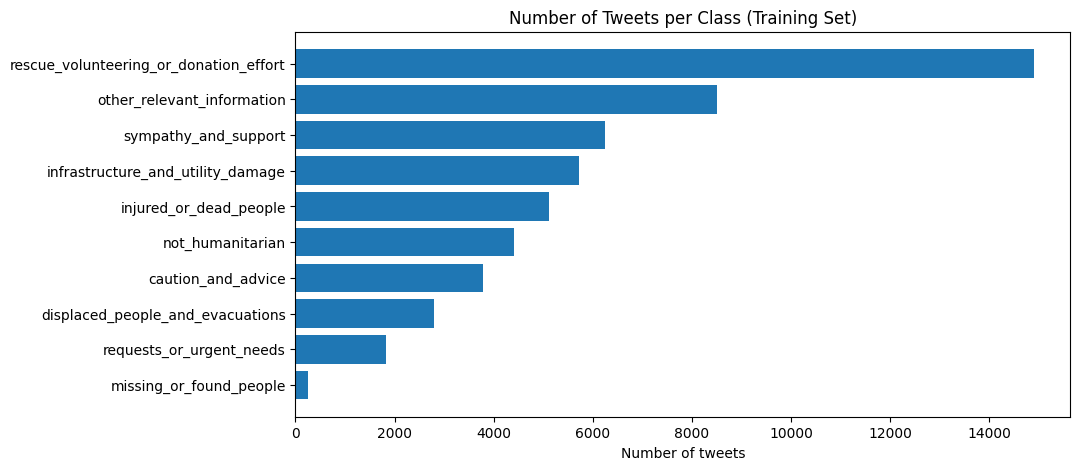

In [24]:
import matplotlib.pyplot as plt

sorted_counts = label_counts.sort_values()

plt.figure(figsize=(10, 5))
plt.barh(sorted_counts.index, sorted_counts.values)
plt.title("Number of Tweets per Class (Training Set)")
plt.xlabel("Number of tweets")
plt.savefig("results/class_distribution.png", bbox_inches="tight")
plt.show()

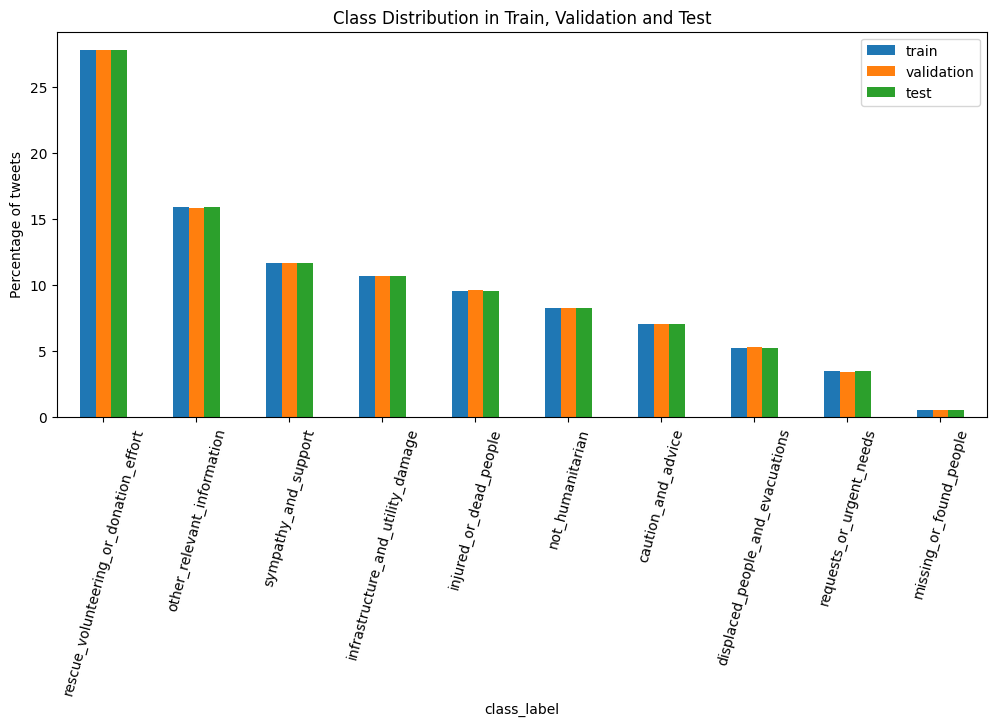

In [25]:
split_comparison.plot(kind="bar", figsize=(12, 5))
plt.title("Class Distribution in Train, Validation and Test")
plt.ylabel("Percentage of tweets")
plt.xticks(rotation=75)
plt.savefig("results/class_distribution_across_splits.png", bbox_inches="tight")
plt.show()

### Tweet Length

The length of the tweets decides the `max_len` we will use when padding sequences for the RNN, LSTM and GRU
models later, so we look at how the lengths are spread out.

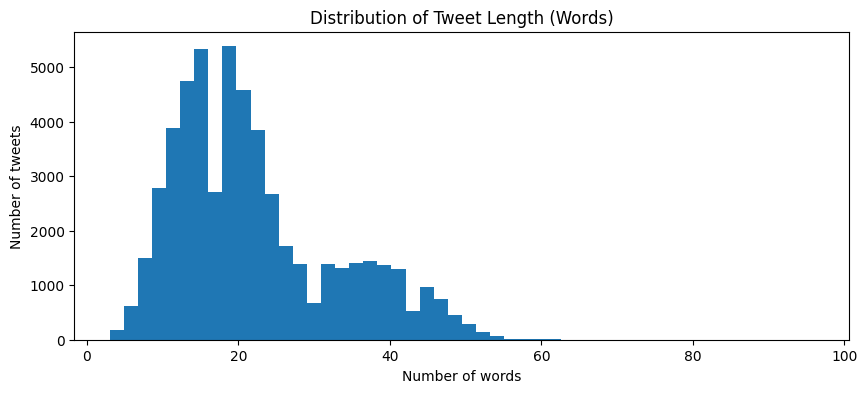

In [26]:
plt.figure(figsize=(10, 4))
plt.hist(train_df["word_count"], bins=50)
plt.title("Distribution of Tweet Length (Words)")
plt.xlabel("Number of words")
plt.ylabel("Number of tweets")
plt.savefig("results/tweet_length_words.png", bbox_inches="tight")
plt.show()

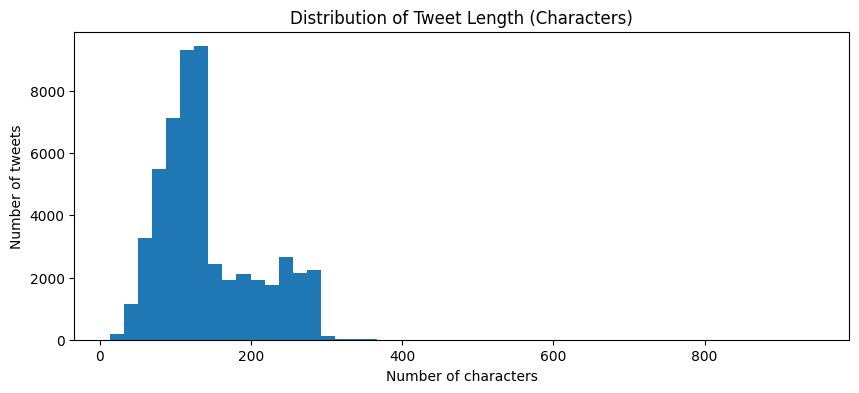

In [27]:
plt.figure(figsize=(10, 4))
plt.hist(train_df["char_length"], bins=50)
plt.title("Distribution of Tweet Length (Characters)")
plt.xlabel("Number of characters")
plt.ylabel("Number of tweets")
plt.savefig("results/tweet_length_characters.png", bbox_inches="tight")
plt.show()

In [28]:
# We use these later to pick max_len

print("90th percentile:", train_df["word_count"].quantile(0.90))
print("95th percentile:", train_df["word_count"].quantile(0.95))
print("99th percentile:", train_df["word_count"].quantile(0.99))
print("Longest tweet:", train_df["word_count"].max())

90th percentile: 39.0
95th percentile: 44.0
99th percentile: 50.0
Longest tweet: 96


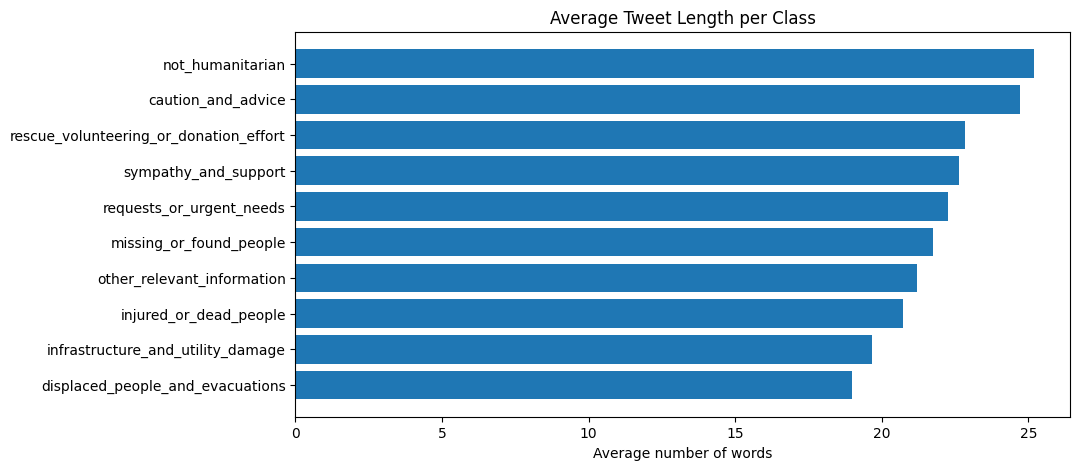

In [29]:
avg_words = train_df.groupby("class_label")["word_count"].mean()
avg_words = avg_words.sort_values()

plt.figure(figsize=(10, 5))
plt.barh(avg_words.index, avg_words.values)
plt.title("Average Tweet Length per Class")
plt.xlabel("Average number of words")
plt.savefig("results/average_tweet_length_per_class.png", bbox_inches="tight")
plt.show()

### Word Frequency

We tokenise the tweets, drop punctuation and stopwords, and look at which words dominate the dataset.

In [30]:
# Most frequent words, stopwords removed

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

stop_words = stopwords.words("english")

all_words = []
for tweet in train_df["tweet_text"]:
    tokens = word_tokenize(tweet.lower())
    for token in tokens:
        if token.isalpha() and token not in stop_words:
            all_words.append(token)

word_count = FreqDist(all_words)

print("Total words:", len(all_words))
print("Different words:", len(word_count))
print()
print(word_count.most_common(20))

Total words: 726623
Different words: 54315

[('hurricane', 11416), ('rt', 8214), ('help', 7580), ('people', 6230), ('amp', 5836), ('relief', 5428), ('earthquake', 4573), ('harvey', 4338), ('california', 4051), ('damage', 3931), ('irma', 3899), ('victims', 3869), ('affected', 3760), ('kerala', 3666), ('flood', 3566), ('dorian', 3431), ('please', 3410), ('water', 3209), ('keralafloods', 2892), ('donate', 2767)]


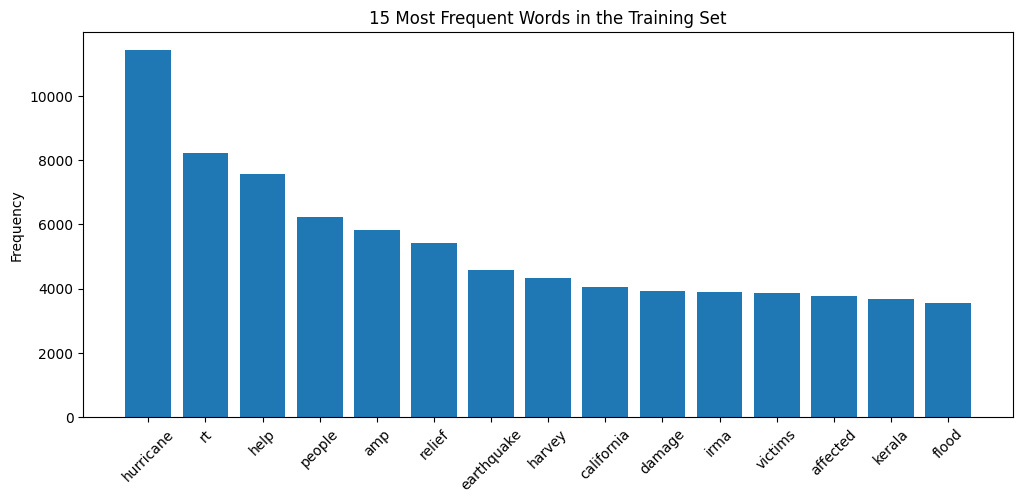

In [31]:
word = []
count = []
for tup in word_count.most_common(15):
    word.append(tup[0])
    count.append(tup[1])

plt.figure(figsize=(12, 5))
plt.bar(word, count)
plt.title("15 Most Frequent Words in the Training Set")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.savefig("results/top_15_words.png", bbox_inches="tight")
plt.show()

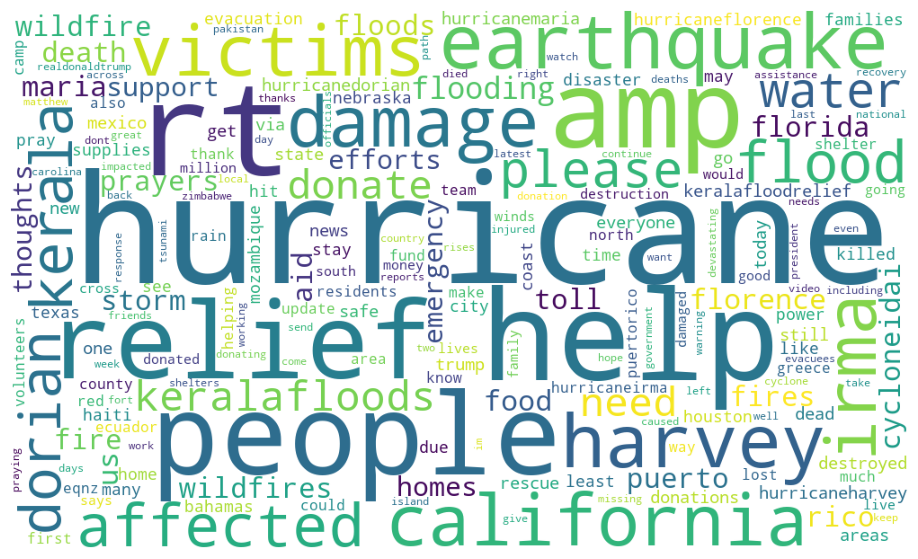

In [32]:
from wordcloud import WordCloud

wc = WordCloud(width=1000, height=600, background_color="white")
cloud = wc.generate_from_frequencies(word_count)

plt.figure(figsize=(12, 7))
plt.imshow(cloud)
plt.axis("off")
plt.savefig("results/wordcloud_training_set.png", bbox_inches="tight")
plt.show()

In [33]:
# Top words in each class

for label in class_labels:
    class_tweets = train_df[train_df["class_label"] == label]["tweet_text"]

    class_words = []
    for tweet in class_tweets:
        tokens = word_tokenize(tweet.lower())
        for token in tokens:
            if token.isalpha() and token not in stop_words:
                class_words.append(token)

    class_word_count = FreqDist(class_words)

    print(label)
    print(class_word_count.most_common(10))
    print()

caution_and_advice
[('hurricane', 1272), ('dorian', 713), ('storm', 708), ('emergency', 685), ('flooding', 652), ('warning', 620), ('florence', 548), ('rt', 510), ('water', 453), ('flood', 436)]



displaced_people_and_evacuations
[('evacuation', 969), ('hurricane', 910), ('evacuees', 491), ('evacuations', 445), ('harvey', 402), ('mandatory', 394), ('irma', 390), ('rt', 377), ('evacuate', 348), ('dorian', 341)]



infrastructure_and_utility_damage
[('damage', 2868), ('hurricane', 1894), ('destroyed', 1002), ('irma', 925), ('rt', 838), ('maria', 670), ('harvey', 624), ('damaged', 590), ('homes', 535), ('puerto', 492)]



injured_or_dead_people
[('death', 1891), ('toll', 1867), ('people', 1716), ('dead', 1150), ('california', 1102), ('rt', 1013), ('least', 942), ('earthquake', 940), ('killed', 916), ('hurricane', 827)]

missing_or_found_people
[('missing', 221), ('california', 109), ('maryland', 94), ('wildfires', 71), ('people', 60), ('city', 54), ('still', 51), ('ellicott', 46), ('flash', 42), ('rt', 42)]



not_humanitarian
[('california', 744), ('fires', 629), ('hurricane', 534), ('trump', 519), ('amp', 409), ('people', 402), ('water', 385), ('rt', 349), ('dorian', 347), ('help', 307)]



other_relevant_information
[('hurricane', 2021), ('rt', 1049), ('water', 894), ('irma', 871), ('flooding', 860), ('harvey', 807), ('amp', 799), ('dorian', 664), ('flood', 627), ('california', 620)]



requests_or_urgent_needs
[('help', 1214), ('need', 765), ('please', 645), ('food', 339), ('people', 319), ('rt', 311), ('water', 288), ('hurricane', 262), ('keralafloods', 239), ('amp', 223)]



rescue_volunteering_or_donation_effort
[('relief', 4120), ('help', 4068), ('hurricane', 2625), ('donate', 2514), ('rt', 2384), ('victims', 2178), ('amp', 2001), ('kerala', 1978), ('affected', 1537), ('keralafloods', 1515)]



sympathy_and_support
[('prayers', 1791), ('thoughts', 1537), ('earthquake', 1385), ('affected', 1355), ('rt', 1341), ('people', 1183), ('help', 1137), ('hurricane', 1071), ('amp', 1001), ('please', 910)]



### Twitter Specific Patterns

Tweets carry retweet prefixes, mentions, hashtags and HTML entities. Counting them tells us what the
preprocessing step in 3.4 actually needs to handle.

In [34]:
# Twitter noise we may need to clean

retweets = train_df["tweet_text"].str.startswith("RT ").sum()
mentions = train_df["tweet_text"].str.contains("@").sum()
hashtag_tweets = train_df["tweet_text"].str.contains("#").sum()
links = train_df["tweet_text"].str.contains("http").sum()
html_entities = train_df["tweet_text"].str.contains("&amp;").sum()

print("Tweets starting with RT:", retweets, "->", round(retweets / len(train_df) * 100, 2), "%")
print("Tweets with @mentions:", mentions, "->", round(mentions / len(train_df) * 100, 2), "%")
print("Tweets with #hashtags:", hashtag_tweets, "->", round(hashtag_tweets / len(train_df) * 100, 2), "%")
print("Tweets with links:", links, "->", round(links / len(train_df) * 100, 2), "%")
print("Tweets with &amp; entities:", html_entities, "->", round(html_entities / len(train_df) * 100, 2), "%")

Tweets starting with RT: 7742 -> 14.46 %
Tweets with @mentions: 20873 -> 38.99 %
Tweets with #hashtags: 30240 -> 56.49 %
Tweets with links: 194 -> 0.36 %
Tweets with &amp; entities: 4629 -> 8.65 %


### EDA Findings

**Missing values.** None, and no empty tweets. Nothing needs dropping.

**Duplicates.** Very clean. No duplicate rows in train, one each in validation and test, and no tweet with two
different labels. Nothing leaks from train into test, so our final scores are honest.

**Class imbalance.** The real problem: 14,891 tweets in the biggest class against 250 in the smallest, about
60 to 1. A model that always guesses the biggest class already looks 28% accurate without learning anything,
which is why we report **macro F1** everywhere instead of trusting accuracy. It also means
`missing_or_found_people` will probably be the hardest class.

**Tweet length.** Median 19 words, 99th percentile 50. So `max_len = 50` will cover almost every tweet later.

**Vocabulary.** The frequent words fit crisis data: *hurricane*, *help*, *relief*, *damage*. But two of the top
five are not words at all: **`rt` (8,214) and `amp` (5,836)**, and the stopword list catches neither. Per class
the vocabulary really does differ, except for `other_relevant_information` and `not_humanitarian`, which
overlap with everything, so we expect most confusion there.

**Twitter patterns.** 14.46% start with `RT`, 38.99% have a mention, 56.49% have a hashtag, 8.65% still contain
`&amp;`. Links are already gone. These numbers decide what 3.4 has to clean.

## 3.4 Data Preprocessing

The EDA in 3.3 told us exactly what is wrong with this text: retweet prefixes, mentions, hashtags and HTML
entities. In this section we build a cleaning function that fixes those problems, then we build several
different preprocessing strategies and **test them against each other** instead of assuming which one is best.

### Removing Duplicates

The EDA in 3.3 found a small number of duplicated rows, plus a few validation tweets that also appear in the
training set. We remove them here, before any cleaning, so that every step after this point works on clean
data. The counts are tiny, but a duplicated tweet is counted twice by the model and a validation tweet that
the model has already trained on makes the validation score slightly optimistic.

In [35]:
# Drop duplicate tweets

print("Before removing duplicates:")
print("   train      :", train_df.shape)
print("   validation :", val_df.shape)
print("   test       :", test_df.shape)

train_df = train_df.drop_duplicates(subset="tweet_text").reset_index(drop=True)
val_df = val_df.drop_duplicates(subset="tweet_text").reset_index(drop=True)
test_df = test_df.drop_duplicates(subset="tweet_text").reset_index(drop=True)

print()
print("After removing duplicates:")
print("   train      :", train_df.shape)
print("   validation :", val_df.shape)
print("   test       :", test_df.shape)

Before removing duplicates:
   train      : (53531, 4)
   validation : (7793, 2)
   test       : (15160, 2)

After removing duplicates:
   train      : (53531, 4)
   validation : (7792, 2)
   test       : (15159, 2)


In [36]:
# Drop validation tweets that also appear in training

train_texts = set(train_df["tweet_text"])

print("Validation rows before:", len(val_df))

val_df = val_df[~val_df["tweet_text"].isin(train_texts)].reset_index(drop=True)

print("Validation rows after :", len(val_df))
print()
print("Tweets still shared between train and validation:",
      len(train_texts.intersection(set(val_df["tweet_text"]))))
print("Tweets still shared between train and test:",
      len(train_texts.intersection(set(test_df["tweet_text"]))))

Validation rows before: 7792
Validation rows after : 7788

Tweets still shared between train and validation: 0
Tweets still shared between train and test: 0


### Cleaning Decisions

Every step is backed by a number we measured in 3.3.

| Step | Decision | Why |
|---|---|---|
| Lowercasing | Yes | *Hurricane* and *hurricane* are the same word |
| Retweet marker `rt` | Remove everywhere | 2nd most common token, 8,214 times. It also appears mid tweet, so removing only the `RT @user:` prefix leaves hundreds behind |
| `@mentions` | Remove | In 38.99% of tweets, and a username never generalises to a new disaster |
| URLs | Remove | Only 0.36% left, and they are meaningless tokens |
| HTML entities like `&amp;` | Remove, semicolon optional | In 8.65% of tweets, and the cause of the junk token `amp`. Truncated tweets contain a bare `&amp` |
| Hashtag symbol `#` | Remove the symbol, **keep the word** | 56.49% of tweets have one, and the common ones are disaster names, so `#keralafloods` becomes `keralafloods` |
| Digits and punctuation | Remove | Same `isalpha()` filtering as Lab 1. *"233 dead"* does not transfer to a new disaster |
| Extra whitespace | Collapse | Removing the parts above leaves gaps |

In [37]:
# The cleaning function

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"&\w+;?", " ", text)
    text = re.sub(r"\brt\b", " ", text)
    text = text.replace("#", " ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

for tweet in train_df["tweet_text"].head(3):
    print("BEFORE:", tweet)
    print("AFTER :", clean_text(tweet))
    print()

BEFORE:

 Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un
AFTER : powerful ecuador quake kills at least portoviejo rescuers in ecuador raced to dig out people trapped un

BEFORE: Im at awe and saddened with the #EcuadorEarthquake Please any donations can help the most unfortunate!
AFTER : im at awe and saddened with the ecuadorearthquake please any donations can help the most unfortunate

BEFORE: RT @RachelAndJun: Our hearts are with everyone in Kumamoto and Ecuador whos been affected by these earthquakes. :( This is has been a terr
AFTER : our hearts are with everyone in kumamoto and ecuador whos been affected by these earthquakes this is has been a terr



### Steps We Test Instead of Assume

Stopword removal, stemming and lemmatization usually get applied without asking whether they help. We measure
each one instead.

Lab 1 showed the two behave differently: the Porter stemmer cuts a word to a stub (`donations` to `donat`),
while the lemmatizer returns a real word (`victims` to `victim`). That difference matters later.

In [38]:
# Stopwords, stemming, lemmatization

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

stop_words = stopwords.words("english")
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def remove_stopwords(text):
    kept = []
    for word in text.split():
        if word not in stop_words:
            kept.append(word)
    return " ".join(kept)

def apply_stemming(text):
    stemmed = []
    for word in text.split():
        stemmed.append(stemmer.stem(word))
    return " ".join(stemmed)

def apply_lemmatization(text):
    lemmatized = []
    for word in text.split():
        lemmatized.append(lemmatizer.lemmatize(word))
    return " ".join(lemmatized)

example = clean_text(train_df["tweet_text"][2])

print("Cleaned      :", example)
print("No stopwords :", remove_stopwords(example))
print("Stemmed      :", apply_stemming(remove_stopwords(example)))
print("Lemmatized   :", apply_lemmatization(remove_stopwords(example)))

Cleaned      : our hearts are with everyone in kumamoto and ecuador whos been affected by these earthquakes this is has been a terr
No stopwords : hearts everyone kumamoto ecuador whos affected earthquakes terr
Stemmed      : heart everyon kumamoto ecuador who affect earthquak terr


Lemmatized   : heart everyone kumamoto ecuador who affected earthquake terr


### Building the Five Strategies

Each strategy adds one step to the one before, so any change in score can be traced to the step that was
added.

1. **Raw text**
2. **Basic cleaning**
3. **Basic + stopword removal**
4. **Basic + stopwords + stemming**
5. **Basic + stopwords + lemmatization**

In [39]:
# Apply everything to all three splits

for df in [train_df, val_df, test_df]:
    df["clean_basic"] = df["tweet_text"].apply(clean_text)
    df["clean_no_stopwords"] = df["clean_basic"].apply(remove_stopwords)
    df["clean_stemmed"] = df["clean_no_stopwords"].apply(apply_stemming)
    df["clean_lemmatized"] = df["clean_no_stopwords"].apply(apply_lemmatization)

strategy_columns = ["tweet_text", "clean_basic", "clean_no_stopwords", "clean_stemmed", "clean_lemmatized"]
strategy_names = ["Raw text", "Basic cleaning", "Basic + stopwords",
                  "Basic + stopwords + stemming", "Basic + stopwords + lemmatization"]

print("Preprocessing finished for all three splits.")
print()
print("Columns now in the training set:")
print(train_df.columns.tolist())

Preprocessing finished for all three splits.

Columns now in the training set:
['tweet_text', 'class_label', 'char_length', 'word_count', 'clean_basic', 'clean_no_stopwords', 'clean_stemmed', 'clean_lemmatized']


In [40]:
# One tweet through all five strategies

sample_tweet_index = 2

for column in strategy_columns:
    print(column)
    print("   ", train_df[column][sample_tweet_index])
    print()

tweet_text
    RT @RachelAndJun: Our hearts are with everyone in Kumamoto and Ecuador whos been affected by these earthquakes. :( This is has been a terr

clean_basic
    our hearts are with everyone in kumamoto and ecuador whos been affected by these earthquakes this is has been a terr

clean_no_stopwords
    hearts everyone kumamoto ecuador whos affected earthquakes terr

clean_stemmed
    heart everyon kumamoto ecuador who affect earthquak terr

clean_lemmatized
    heart everyone kumamoto ecuador who affected earthquake terr



### Did the Cleaning Actually Fix the Problem Found in 3.3?

In 3.3 we found that `rt` and `amp` were among the five most frequent words in the dataset. This is a direct
check that our cleaning removed them. We count with `word_tokenize`, the same tokenizer used in 3.3, so that
the before and after numbers are measured the same way and can honestly be compared.

In [41]:
# Did we actually get rid of rt and amp?

from nltk.tokenize import word_tokenize

def count_token(texts, token):
    total = 0
    for text in texts:
        for word in word_tokenize(text.lower()):
            if word == token:
                total += 1
    return total

print("Occurrences of 'rt':")
print("   before cleaning:", count_token(train_df["tweet_text"], "rt"))
print("   after cleaning :", count_token(train_df["clean_basic"], "rt"))
print()
print("Occurrences of 'amp':")
print("   before cleaning:", count_token(train_df["tweet_text"], "amp"))
print("   after cleaning :", count_token(train_df["clean_basic"], "amp"))

Occurrences of 'rt':


   before cleaning: 8214


   after cleaning : 3

Occurrences of 'amp':


   before cleaning: 5836


   after cleaning : 20


In [42]:
# Vocabulary size of each strategy

vocabulary_sizes = []

for column in strategy_columns:
    words = []
    for text in train_df[column]:
        for word in text.split():
            words.append(word)

    vocabulary_sizes.append(len(set(words)))

    print(column)
    print("   total words:", len(words), "| different words:", len(set(words)))

tweet_text
   total words: 1183702 | different words: 121237


clean_basic
   total words: 1119619 | different words: 42263


clean_no_stopwords
   total words: 708708 | different words: 42114


clean_stemmed
   total words: 708708 | different words: 32743


clean_lemmatized
   total words: 708708 | different words: 38635


### Comparing the Strategies

Reading the cleaned text is not enough to pick a winner. Each strategy becomes TF-IDF features and goes into a
quick Logistic Regression, scored on the **validation** set. The test set stays untouched, and we report macro
F1 because of the imbalance.

In [43]:
# Score every strategy with the same baseline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

y_train = train_df["class_label"]
y_val = val_df["class_label"]

accuracy_results = []
f1_results = []

for column in strategy_columns:
    vectorizer = TfidfVectorizer(max_features=5000)
    X_train = vectorizer.fit_transform(train_df[column])
    X_val = vectorizer.transform(val_df[column])

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    accuracy = accuracy_score(y_val, predictions)
    macro_f1 = f1_score(y_val, predictions, average="macro")

    accuracy_results.append(accuracy)
    f1_results.append(macro_f1)

    print(column, "-> accuracy:", round(accuracy, 4), "| macro F1:", round(macro_f1, 4))

tweet_text -> accuracy: 0.7396 | macro F1: 0.7076


clean_basic -> accuracy: 0.7384 | macro F1: 0.7069


clean_no_stopwords -> accuracy: 0.7379 | macro F1: 0.7054


clean_stemmed -> accuracy: 0.7423 | macro F1: 0.7074


clean_lemmatized -> accuracy: 0.7422 | macro F1: 0.706


In [44]:
# Put it in a table

preprocessing_comparison = pd.DataFrame({
    "strategy": strategy_names,
    "validation_accuracy": accuracy_results,
    "validation_macro_f1": f1_results
})

preprocessing_comparison.round(4)

,strategy,validation_accuracy,validation_macro_f1
0,Raw text,0.7396,0.7076
1,Basic cleaning,0.7384,0.7069
2,Basic + stopwords,0.7379,0.7054
3,Basic + stopwords + stemming,0.7423,0.7074
4,Basic + stopwords + lemmatization,0.7422,0.7060


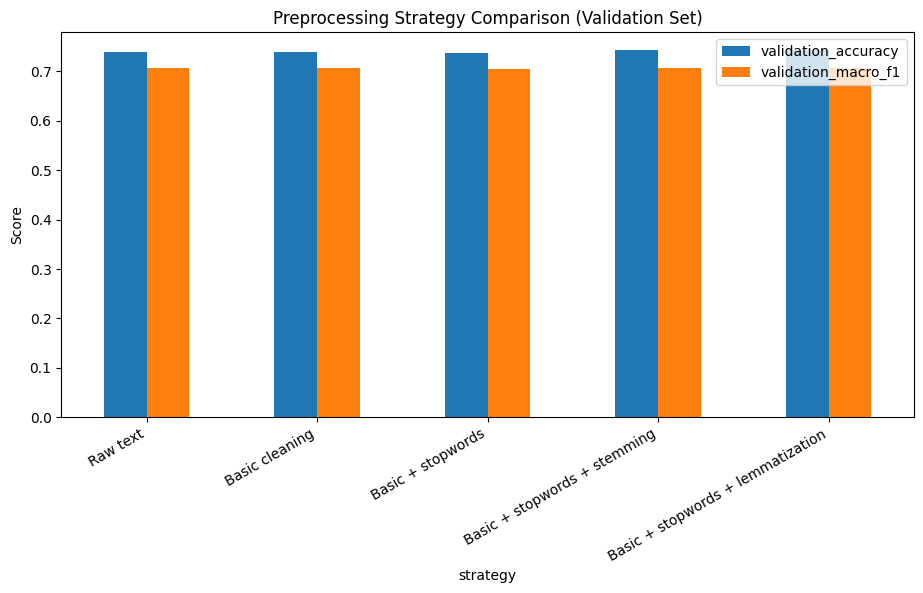

In [45]:
preprocessing_comparison.plot(x="strategy", kind="bar", figsize=(11, 5))
plt.title("Preprocessing Strategy Comparison (Validation Set)")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.savefig("results/preprocessing_strategy_comparison.png", bbox_inches="tight")
plt.show()

In [46]:
# How big is the difference really?

best_f1 = max(f1_results)

print("Highest macro F1:", round(best_f1, 4))
print("Difference between best and worst macro F1:", round(best_f1 - min(f1_results), 4))
print("Difference between best and worst accuracy:", round(max(accuracy_results) - min(accuracy_results), 4))

Highest macro F1: 0.7076
Difference between best and worst macro F1: 0.0022
Difference between best and worst accuracy: 0.0044


### Final Decision and Justification

**Preprocessing barely changed the score.** All five strategies land within about 0.002 macro F1, well inside
normal noise. That makes sense: TF-IDF already down weights words like `rt` and `amp` because they appear
everywhere.

That creates a trap. Taking the single highest number would select **raw, unprocessed text**, because it came
out a fraction ahead by chance. So we use a two step rule:

1. Keep every strategy within `0.01` macro F1 of the best, since they are tied
2. Among those, take the **smallest vocabulary**

That is where preprocessing actually pays off: vocabulary falls from 121,237 words to about 33,000, a 73% cut,
which directly shrinks the embedding matrix the neural models build in 3.7.

**Note for 3.6.** Stemming gives stubs that are not real words, `earthquake` becomes `earthquak`. Fine for
TF-IDF, a problem for pretrained GloVe. So we keep every strategy column instead of overwriting the text.

In [47]:
# Tied on score, so pick the smallest vocabulary

tolerance = 0.01

tied_strategies = []
for i in range(len(strategy_columns)):
    if best_f1 - f1_results[i] <= tolerance:
        tied_strategies.append(i)

best_index = tied_strategies[0]
for i in tied_strategies:
    if vocabulary_sizes[i] < vocabulary_sizes[best_index]:
        best_index = i

best_column = strategy_columns[best_index]

print("Strategies tied with the best score:")
for i in tied_strategies:
    print("   ", strategy_names[i], "| macro F1:", round(f1_results[i], 4), "| vocabulary:", vocabulary_sizes[i])

print()
print("Chosen strategy:", strategy_names[best_index])
print("Chosen column  :", best_column)

Strategies tied with the best score:
    Raw text | macro F1: 0.7076 | vocabulary: 121237
    Basic cleaning | macro F1: 0.7069 | vocabulary: 42263
    Basic + stopwords | macro F1: 0.7054 | vocabulary: 42114
    Basic + stopwords + stemming | macro F1: 0.7074 | vocabulary: 32743
    Basic + stopwords + lemmatization | macro F1: 0.706 | vocabulary: 38635

Chosen strategy: Basic + stopwords + stemming
Chosen column  : clean_stemmed


In [48]:
# The text column we use from here on

train_df["final_text"] = train_df[best_column]
val_df["final_text"] = val_df[best_column]
test_df["final_text"] = test_df[best_column]

print("Column chosen for modelling:", best_column)
print()
print(train_df[["tweet_text", "final_text", "class_label"]].head())

Column chosen for modelling: clean_stemmed

                                          tweet_text  \
0  Powerful Ecuador quake kills at least 235: POR...   
1  Im at awe and saddened with the #EcuadorEarthq...   
2  RT @RachelAndJun: Our hearts are with everyone...   
3  RT @noticias2000: Ecuador quake death toll has...   
4  RT @pzf: BREAKING PHOTOS: Major damage reporte...   

                                          final_text  \
0  power ecuador quak kill least portoviejo rescu...   
1  im awe sadden ecuadorearthquak pleas donat hel...   
2  heart everyon kumamoto ecuador who affect eart...   
3  ecuador quak death toll risen correa confirm p...   
4  break photo major damag report ecuador massiv ...   

                              class_label  
0                  injured_or_dead_people  
1  rescue_volunteering_or_donation_effort  
2                    sympathy_and_support  
3                  injured_or_dead_people  
4       infrastructure_and_utility_damage  


In [49]:
# Did cleaning empty any tweet?

print("Empty texts after preprocessing:")
print("   train      :", (train_df["final_text"].str.strip() == "").sum())
print("   validation :", (val_df["final_text"].str.strip() == "").sum())
print("   test       :", (test_df["final_text"].str.strip() == "").sum())

Empty texts after preprocessing:
   train      : 0
   validation : 0
   test       : 0


### Summary of 3.4

- One `clean_text` function handles lowercasing, retweet markers, mentions, URLs, HTML entities and hashtags,
  every decision backed by a measurement.
- We **checked** the cleaning instead of trusting it, and the check caught two real bugs. `rt` fell from 8,214
  to 3 and `amp` from 5,836 to 20. The leftover comes from double encoded `&amp;amp;` and is worth reporting
  honestly rather than claiming a perfect result.
- Duplicates were removed, including validation tweets that also appeared in training.
- The five strategies came out **tied**, so the winner was picked by an explicit rule rather than by noise. No
  tweet became empty.

## 3.5 Train / Validation / Test Split

HumAID already ships with an **official split**, and we use it instead of making our own:

- It is **already stratified**, checked in 3.2 and checked again below since 3.4 removed rows
- It is **reproducible by design**, since it lives in three fixed files with no random shuffle
- It keeps our results **comparable** with the published benchmark, which uses this exact split
- The ratio is sensible: about 70 / 10 / 20, with a test set of over 15,000 tweets

Validation is used for all tuning in 3.8. **The test set is not touched until 3.9.**

In [50]:
# Split sizes after removing duplicates

total = len(train_df) + len(val_df) + len(test_df)

print("Train:", len(train_df), "tweets")
print("Validation:", len(val_df), "tweets")
print("Test:", len(test_df), "tweets")
print()
print("Train percentage:", round(len(train_df) / total * 100, 2))
print("Validation percentage:", round(len(val_df) / total * 100, 2))
print("Test percentage:", round(len(test_df) / total * 100, 2))

Train: 53531 tweets
Validation: 7788 tweets
Test: 15159 tweets

Train percentage: 70.0
Validation percentage: 10.18
Test percentage: 19.82


### Is the Split Still Balanced After Removing Duplicates?

3.4 removed rows from the validation and test sets, so the stratification we verified in 3.2 has to be
checked again rather than assumed.

In [51]:
# Are the splits still balanced?

train_percent = train_df.value_counts("class_label", normalize=True) * 100
val_percent = val_df.value_counts("class_label", normalize=True) * 100
test_percent = test_df.value_counts("class_label", normalize=True) * 100

final_split_check = pd.DataFrame({
    "train": train_percent,
    "validation": val_percent,
    "test": test_percent
})

final_split_check.round(2)

,train,validation,test
class_label,,,
rescue_volunteering_or_donation_effort,27.82,27.82,27.83
other_relevant_information,15.88,15.87,15.88
sympathy_and_support,11.68,11.63,11.69
infrastructure_and_utility_damage,10.68,10.66,10.67
injured_or_dead_people,9.55,9.58,9.55
not_humanitarian,8.23,8.27,8.21
caution_and_advice,7.05,7.06,7.06
displaced_people_and_evacuations,5.23,5.25,5.21
requests_or_urgent_needs,3.42,3.39,3.44


In [52]:
# No class should be missing

print("Classes in train:", train_df["class_label"].nunique())
print("Classes in validation:", val_df["class_label"].nunique())
print("Classes in test:", test_df["class_label"].nunique())
print()
print("Smallest class in train:", train_df.value_counts("class_label").min(), "tweets")
print("Smallest class in validation:", val_df.value_counts("class_label").min(), "tweets")
print("Smallest class in test:", test_df.value_counts("class_label").min(), "tweets")

Classes in train: 10


Classes in validation: 10
Classes in test: 10

Smallest class in train: 250 tweets
Smallest class in validation: 36 tweets
Smallest class in test: 72 tweets


In [53]:
# No tweet should be in two splits

train_texts = set(train_df["tweet_text"])
val_texts = set(val_df["tweet_text"])
test_texts = set(test_df["tweet_text"])

print("Shared between train and validation:", len(train_texts.intersection(val_texts)))
print("Shared between train and test:", len(train_texts.intersection(test_texts)))
print("Shared between validation and test:", len(val_texts.intersection(test_texts)))

Shared between train and validation: 0
Shared between train and test: 0
Shared between validation and test: 0


### Reproducibility

The split itself is fixed, but model training is not: weight initialisation and shuffling are random. We set
a seed here so the whole notebook can be re-run with the same results.

In [54]:
# Fix the seeds so this can be reproduced

import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)

print("Random seed set to:", seed)

Random seed set to: 42


### Preparing the Text and the Labels

Here we create the variables that every model from 3.6 onwards will use. The text comes from the `final_text`
column chosen in 3.4.

The labels are still words, and that is a problem for the neural models: Keras needs numbers, not strings. So
we encode them with `LabelEncoder`, exactly as in Lab 2.

In [55]:
# The text the models will use

X_train_text = train_df["final_text"]
X_val_text = val_df["final_text"]
X_test_text = test_df["final_text"]

print("Train text shape:", X_train_text.shape)
print("Validation text shape:", X_val_text.shape)
print("Test text shape:", X_test_text.shape)
print()
print(X_train_text.head())

Train text shape: (53531,)
Validation text shape: (7788,)
Test text shape: (15159,)

0    power ecuador quak kill least portoviejo rescu...
1    im awe sadden ecuadorearthquak pleas donat hel...
2    heart everyon kumamoto ecuador who affect eart...
3    ecuador quak death toll risen correa confirm p...
4    break photo major damag report ecuador massiv ...
Name: final_text, dtype: object


In [56]:
# Labels as numbers, Keras needs numbers

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(train_df["class_label"])
y_val = le.transform(val_df["class_label"])
y_test = le.transform(test_df["class_label"])

for i in range(len(le.classes_)):
    print(i, "->", le.classes_[i])

0 -> caution_and_advice
1 -> displaced_people_and_evacuations
2 -> infrastructure_and_utility_damage
3 -> injured_or_dead_people
4 -> missing_or_found_people
5 -> not_humanitarian
6 -> other_relevant_information
7 -> requests_or_urgent_needs
8 -> rescue_volunteering_or_donation_effort
9 -> sympathy_and_support


In [57]:
# Check the encoding worked

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)
print()
print("First 10 encoded labels:", y_train[:10])
print("First 10 original labels:", train_df["class_label"].head(10).tolist())

y_train shape: (53531,)
y_val shape: (7788,)
y_test shape: (15159,)

First 10 encoded labels: [3 8 9 3 2 3 8 8 8 3]
First 10 original labels: ['injured_or_dead_people', 'rescue_volunteering_or_donation_effort', 'sympathy_and_support', 'injured_or_dead_people', 'infrastructure_and_utility_damage', 'injured_or_dead_people', 'rescue_volunteering_or_donation_effort', 'rescue_volunteering_or_donation_effort', 'rescue_volunteering_or_donation_effort', 'injured_or_dead_people']


### Summary of 3.5

- We reuse the official split. It is reproducible because it comes from fixed files, and it keeps our results
  comparable with the published benchmark.
- After removing duplicates: **53,531 / 7,788 / 15,159**, still stratified, all ten classes present, and no
  tweet shared between splits.
- Seed 42 is set. `X_train_text` and friends hold the text, `y_train` and friends hold labels as numbers 0 to 9.

## 3.6 Text Representation

A model cannot read words, so text has to become numbers. The project asks for at least two of TF-IDF,
Word2Vec and GloVe. We do **all three**, plus the integer sequences the recurrent models need in 3.7, and
measure each with the same Logistic Regression baseline.

| Representation | What it captures | Size |
|---|---|---|
| **TF-IDF** | How important a word is to a tweet compared with the whole corpus | thousands |
| **Word2Vec** | Meaning learned from *our own* tweets | 100 |
| **GloVe** | Meaning learned in advance from Wikipedia | 50 |

For Word2Vec and GloVe a tweet becomes one vector by **averaging the vectors of its words**.

In [58]:
# One scoring function, so every representation is judged the same way

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

representation_names = []
representation_accuracy = []
representation_f1 = []

def evaluate_representation(X_train, X_val, name):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)

    accuracy = accuracy_score(y_val, predictions)
    macro_f1 = f1_score(y_val, predictions, average="macro")

    representation_names.append(name)
    representation_accuracy.append(accuracy)
    representation_f1.append(macro_f1)

    print(name)
    print("   accuracy:", round(accuracy, 4), "| macro F1:", round(macro_f1, 4))

print("Ready to evaluate representations.")

Ready to evaluate representations.


### TF-IDF

TF-IDF gives every word a weight that grows with how often it appears in a tweet and shrinks with how many
tweets contain it. Common words are pushed down automatically, which is why it handled the `rt` and `amp`
noise on its own back in 3.4.

We try three settings to see whether a bigger vocabulary or word pairs help.

In [59]:
# TF-IDF, 5000 words

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

print("Shape of the TF-IDF matrix:", X_train_tfidf.shape)
print()
print("First 20 features in the vocabulary:")
print(tfidf.get_feature_names_out()[:20])

Shape of the TF-IDF matrix: (53531, 5000)

First 20 features in the vocabulary:
['aameen' 'aaron' 'ab' 'abaco' 'abacoisland' 'abandon' 'abbott' 'abc'
 'abfir' 'abil' 'abl' 'aboard' 'abort' 'abroad' 'absolut' 'abt' 'abu'
 'abus' 'abvp' 'ac']


In [60]:
evaluate_representation(X_train_tfidf, X_val_tfidf, "TF-IDF 5000 words")

TF-IDF 5000 words
   accuracy: 0.7423 | macro F1: 0.7074


In [61]:
# TF-IDF, 10000 words

tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

print("Shape:", X_train_tfidf.shape)

evaluate_representation(X_train_tfidf, X_val_tfidf, "TF-IDF 10000 words")

Shape: (53531, 10000)


TF-IDF 10000 words
   accuracy: 0.7428 | macro F1: 0.7074


In [62]:
# TF-IDF with bigrams

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

print("Shape:", X_train_tfidf.shape)
print()
print("Some of the word pairs it learned:")
features = tfidf.get_feature_names_out()
pairs = []
for feature in features:
    if " " in feature:
        pairs.append(feature)
print(pairs[:15])
print()

evaluate_representation(X_train_tfidf, X_val_tfidf, "TF-IDF 10000 + bigrams")

Shape: (53531, 10000)

Some of the word pairs it learned:
['aaron rodger', 'abaco bahama', 'abaco dorian', 'abaco island', 'abandon pet', 'abc news', 'abl get', 'abl help', 'absolut heartbreak', 'abu dhabi', 'accept aid', 'accept donat', 'accept foreign', 'access clean', 'acr burn']



TF-IDF 10000 + bigrams
   accuracy: 0.7451 | macro F1: 0.7142


### Word2Vec

Here we train Word2Vec on our own tweets, using the same settings style as Lab 3. Because it learns from
disaster text, it picks up the vocabulary of this domain rather than general English.

In [63]:
# Train Word2Vec on our own tweets

from gensim.models import Word2Vec

sentences = []
for text in X_train_text:
    sentences.append(text.split())

w2v_model = Word2Vec(vector_size=100, window=5, sg=1, min_count=2, seed=42)
w2v_model.build_vocab(sentences)
w2v_model.train(sentences, total_examples=len(sentences), epochs=5)

print("Sentences used for training:", len(sentences))
print("Words in the Word2Vec vocabulary:", len(w2v_model.wv.index_to_key))
print("Vector size:", w2v_model.wv.vector_size)

Sentences used for training: 53531
Words in the Word2Vec vocabulary: 14418
Vector size: 100


In [64]:
# Do the learned vectors make sense?

print("Words most similar to 'donat':")
for word, score in w2v_model.wv.most_similar("donat", topn=5):
    print("   ", word, round(score, 3))

print()
print("Words most similar to 'evacu':")
for word, score in w2v_model.wv.most_similar("evacu", topn=5):
    print("   ", word, round(score, 3))

Words most similar to 'donat':
    contribut 0.795
    gift 0.739
    paypal 0.729
    campaign 0.726
    econet 0.726

Words most similar to 'evacu':
    mandatori 0.796
    order 0.781
    evac 0.739
    visitor 0.738
    zone 0.707


In [65]:
# Cosine similarity, like Lab 3

from sklearn.metrics.pairwise import cosine_similarity

dead_vector = w2v_model.wv["dead"]
kill_vector = w2v_model.wv["kill"]
donat_vector = w2v_model.wv["donat"]

print("dead  vs kill :", round(cosine_similarity([dead_vector], [kill_vector])[0][0], 4))
print("dead  vs donat:", round(cosine_similarity([dead_vector], [donat_vector])[0][0], 4))

dead  vs kill : 0.8268
dead  vs donat: 0.2561


### Turning Word Vectors into Tweet Vectors

Word2Vec gives one vector per *word*, but the classifier needs one vector per *tweet*. We average the vectors
of all the words in the tweet. Words that are not in the vocabulary are skipped, and a tweet with no known
words at all becomes a vector of zeros.

In [66]:
# Average the word vectors to get one vector per tweet

import numpy as np

def average_vector(text, vectors, size):
    found = []
    for word in text.split():
        if word in vectors:
            found.append(vectors[word])

    if len(found) == 0:
        return np.zeros(size)

    return np.mean(found, axis=0)

example = X_train_text[0]
print("Tweet:", example)
print()
print("Averaged vector (first 10 numbers):")
print(average_vector(example, w2v_model.wv, 100)[:10])

Tweet: power ecuador quak kill least portoviejo rescuer ecuador race dig peopl trap un

Averaged vector (first 10 numbers):
[-0.02757251  0.01023706 -0.706921    0.2617475   0.06162018  0.3164261
 -0.1318224   0.11645103  0.03470876 -0.15466796]


In [67]:
# Build the Word2Vec features

X_train_w2v = []
for text in X_train_text:
    X_train_w2v.append(average_vector(text, w2v_model.wv, 100))

X_val_w2v = []
for text in X_val_text:
    X_val_w2v.append(average_vector(text, w2v_model.wv, 100))

X_train_w2v = np.array(X_train_w2v)
X_val_w2v = np.array(X_val_w2v)

print("Train shape:", X_train_w2v.shape)
print("Validation shape:", X_val_w2v.shape)
print()

evaluate_representation(X_train_w2v, X_val_w2v, "Word2Vec average (100d)")

Train shape: (53531, 100)
Validation shape: (7788, 100)



Word2Vec average (100d)
   accuracy: 0.7179 | macro F1: 0.6744


### GloVe

GloVe vectors come pretrained. Lab 3 read `glove.6B.50d.txt` from Google Drive; here we let `gensim` download
the same 50 dimensional vectors, which it caches so it only downloads once. Everything after loading is used
exactly like the dictionary in Lab 3.

In [68]:
# Load pretrained GloVe

import gensim.downloader as api

glove_model = api.load("glove-wiki-gigaword-50")

print("Words in GloVe:", len(glove_model.index_to_key))
print("Vector size:", glove_model.vector_size)
print()
print("Vector for 'earthquake' (first 10 numbers):")
print(glove_model["earthquake"][:10])

Words in GloVe: 400000
Vector size: 50

Vector for 'earthquake' (first 10 numbers):
[ 1.5208   -0.27971   0.84536   0.47431  -0.35396   0.49079  -0.040919
  0.034508 -0.26081  -0.25874 ]


### The Problem We Predicted in 3.4

Back in 3.4 we noted that the Porter stemmer produces stubs that are not real words, and that pretrained GloVe
would have no vector for them. This is where we test that claim instead of just asserting it.

In [69]:
# How many of our words does GloVe know?

def glove_coverage(texts):
    total = 0
    found = 0
    for text in texts:
        for word in text.split():
            total += 1
            if word in glove_model:
                found += 1
    return found / total * 100

print("'earthquake' in GloVe:", "earthquake" in glove_model)
print("'earthquak' in GloVe :", "earthquak" in glove_model)
print()
print("Coverage using stemmed text   :", round(glove_coverage(train_df["clean_stemmed"]), 2), "%")
print("Coverage using lemmatized text:", round(glove_coverage(train_df["clean_lemmatized"]), 2), "%")

'earthquake' in GloVe: True
'earthquak' in GloVe : False



Coverage using stemmed text   : 76.2 %


Coverage using lemmatized text: 93.48 %


In [70]:
# GloVe on the stemmed text

X_train_glove = []
for text in train_df["clean_stemmed"]:
    X_train_glove.append(average_vector(text, glove_model, 50))

X_val_glove = []
for text in val_df["clean_stemmed"]:
    X_val_glove.append(average_vector(text, glove_model, 50))

X_train_glove = np.array(X_train_glove)
X_val_glove = np.array(X_val_glove)

print("Shape:", X_train_glove.shape)
print()

evaluate_representation(X_train_glove, X_val_glove, "GloVe average on stemmed text")

Shape: (53531, 50)



GloVe average on stemmed text
   accuracy: 0.5375 | macro F1: 0.4344


In [71]:
# GloVe on the lemmatized text instead

X_train_glove = []
for text in train_df["clean_lemmatized"]:
    X_train_glove.append(average_vector(text, glove_model, 50))

X_val_glove = []
for text in val_df["clean_lemmatized"]:
    X_val_glove.append(average_vector(text, glove_model, 50))

X_train_glove = np.array(X_train_glove)
X_val_glove = np.array(X_val_glove)

print("Shape:", X_train_glove.shape)
print()

evaluate_representation(X_train_glove, X_val_glove, "GloVe average on lemmatized text")

Shape: (53531, 50)



GloVe average on lemmatized text
   accuracy: 0.6085 | macro F1: 0.5173


### Integer Sequences for the Recurrent Models

TF-IDF and averaged vectors both throw away word order, so for the RNN models we use the Lab 3 approach: every
word becomes a number and every tweet is padded to the same length.

Both numbers come from the EDA. `num_words = 10000` keeps the most common words, since 3.3 showed a long tail
of words appearing only once. `max_len = 50` is exactly the 99th percentile of tweet length measured in 3.3.

In [72]:
# Map every word to a number

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

num_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

print("Total words the tokenizer saw:", len(tokenizer.word_index))
print("Words it will actually use:", num_words)

Total words the tokenizer saw: 32744
Words it will actually use: 10000


In [73]:
# Turn the text into padded sequences

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

print("Train padded shape:", X_train_pad.shape)
print("Validation padded shape:", X_val_pad.shape)
print("Test padded shape:", X_test_pad.shape)
print()
print("Original tweet:", X_train_text[0])
print()
print("As integers:", X_train_seq[0])
print()
print("After padding:", X_train_pad[0])

Train padded shape: (53531, 50)
Validation padded shape: (7788, 50)
Test padded shape: (15159, 50)

Original tweet: power ecuador quak kill least portoviejo rescuer ecuador race dig peopl trap un

As integers: [83, 135, 309, 58, 94, 4878, 858, 135, 1470, 2629, 6, 716, 1005]

After padding: [  83  135  309   58   94 4878  858  135 1470 2629    6  716 1005    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


### Comparing the Representations

In [74]:
# All representations side by side

representation_comparison = pd.DataFrame({
    "representation": representation_names,
    "validation_accuracy": representation_accuracy,
    "validation_macro_f1": representation_f1
})

representation_comparison.round(4)

,representation,validation_accuracy,validation_macro_f1
0,TF-IDF 5000 words,0.7423,0.7074
1,TF-IDF 10000 words,0.7428,0.7074
2,TF-IDF 10000 + bigrams,0.7451,0.7142
3,Word2Vec average (100d),0.7179,0.6744
4,GloVe average on stemmed text,0.5375,0.4344
5,GloVe average on lemmatized text,0.6085,0.5173


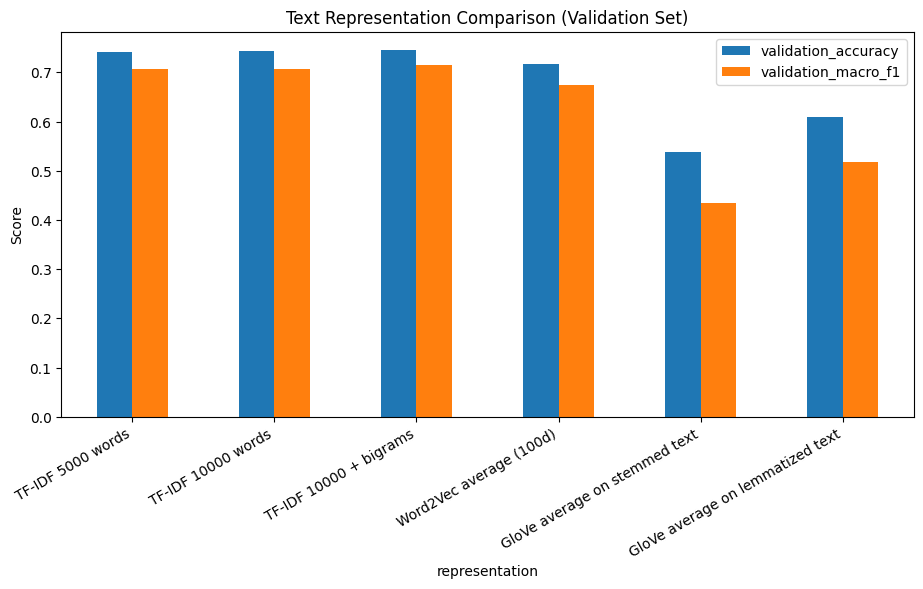

In [75]:
representation_comparison.plot(x="representation", kind="bar", figsize=(11, 5))
plt.title("Text Representation Comparison (Validation Set)")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.savefig("results/text_representation_comparison.png", bbox_inches="tight")
plt.show()

### What the Comparison Showed

**TF-IDF wins, and bigrams make it better.** Going from 5,000 to 10,000 words changed almost nothing, but word
pairs helped, which makes sense: *"death toll"* and *"relief fund"* mean something the separate words do not.

**Word2Vec trained on our own tweets beat pretrained GloVe by a wide margin**, despite learning from only
53,000 short tweets. The reason is vocabulary: our text is full of words like `keralaflood` that GloVe has
never seen.

**The prediction from 3.4 was right.** GloVe knows `earthquake` but not `earthquak`. It covers 76% of our
stemmed tokens against 93% of our lemmatized ones, and that gap turned into a large jump in macro F1. This is
why we kept every preprocessing column.

**Why do averaged embeddings lose?** Averaging is blunt. It blurs the distinctive words into the ordinary ones
and destroys word order, while TF-IDF keeps thousands of separate columns and can weight the few words that
identify a class.

## 3.7 Model Development

Ten models are trained here: three classic models, six recurrent networks and BERT. Each gets **three
hyperparameter configurations**, and the one with the best validation macro F1 is kept. All those runs go into
the tuning table in 3.8.

| Models | Representation | Why |
|---|---|---|
| Logistic Regression, Random Forest, Naive Bayes | TF-IDF, 10,000 features with bigrams | Strongest representation in 3.6 |
| SimpleRNN, GRU, LSTM and bidirectional versions | Padded sequences with a trainable Embedding | They need word order, which TF-IDF throws away |
| BERT | Its own tokenizer on the **raw** tweet | BERT expects normal English, and our stemmed text would break into meaningless pieces |

We select on **macro F1**, not accuracy, because of the 60 to 1 imbalance.

In [88]:
# Features, seeds, and where we collect the results

import os
import tensorflow as tf

tf.random.set_seed(seed)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

os.makedirs("results/models", exist_ok=True)
os.makedirs("results/predictions", exist_ok=True)

tuning_results = []
best_models = {}

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)
print()
print("Sequence train shape:", X_train_pad.shape)
print("Number of classes:", len(le.classes_))

TF-IDF train shape: (53531, 10000)
TF-IDF validation shape: (7788, 10000)
TF-IDF test shape: (15159, 10000)

Sequence train shape: (53531, 50)
Number of classes: 10


### Logistic Regression

The setting we vary is `C`, which controls regularisation. A small `C` regularises harder and keeps the
weights small, a large `C` lets the model fit the training data more closely.

In [89]:
# Logistic Regression, three values of C

logistic_configs = [0.5, 1.0, 5.0]

best_score = -1

for c_value in logistic_configs:
    model = LogisticRegression(C=c_value, max_iter=1000)
    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_val_tfidf)
    accuracy = accuracy_score(y_val, predictions)
    macro_f1 = f1_score(y_val, predictions, average="macro")

    tuning_results.append({
        "model": "Logistic Regression",
        "settings": "C = " + str(c_value),
        "val_accuracy": round(accuracy, 4),
        "val_macro_f1": round(macro_f1, 4)
    })

    print("C =", c_value, "-> accuracy:", round(accuracy, 4), "| macro F1:", round(macro_f1, 4))

    if macro_f1 > best_score:
        best_score = macro_f1
        best_models["Logistic Regression"] = model

print()
print("Best macro F1 for Logistic Regression:", round(best_score, 4))

C = 0.5 -> accuracy: 0.7411 | macro F1: 0.7001


C = 1.0 -> accuracy: 0.7451 | macro F1: 0.7142


C = 5.0 -> accuracy: 0.7345 | macro F1: 0.7037

Best macro F1 for Logistic Regression: 0.7142


### Random Forest

Here we vary the number of trees and how many samples a node needs before it can split.

In [90]:
# Random Forest, three settings

from sklearn.ensemble import RandomForestClassifier

forest_configs = [
    {"n_estimators": 100, "min_samples_split": 2},
    {"n_estimators": 200, "min_samples_split": 2},
    {"n_estimators": 300, "min_samples_split": 5},
]

best_score = -1

for config in forest_configs:
    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        min_samples_split=config["min_samples_split"],
        n_jobs=-1,
        random_state=seed
    )
    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_val_tfidf)
    accuracy = accuracy_score(y_val, predictions)
    macro_f1 = f1_score(y_val, predictions, average="macro")

    settings = "trees = " + str(config["n_estimators"]) + ", min_samples_split = " + str(config["min_samples_split"])

    tuning_results.append({
        "model": "Random Forest",
        "settings": settings,
        "val_accuracy": round(accuracy, 4),
        "val_macro_f1": round(macro_f1, 4)
    })

    print(settings, "-> accuracy:", round(accuracy, 4), "| macro F1:", round(macro_f1, 4))

    if macro_f1 > best_score:
        best_score = macro_f1
        best_models["Random Forest"] = model

print()
print("Best macro F1 for Random Forest:", round(best_score, 4))

trees = 100, min_samples_split = 2 -> accuracy: 0.725 | macro F1: 0.6803


trees = 200, min_samples_split = 2 -> accuracy: 0.7246 | macro F1: 0.6817


trees = 300, min_samples_split = 5 -> accuracy: 0.7278 | macro F1: 0.6883

Best macro F1 for Random Forest: 0.6883


### Naive Bayes

For Multinomial Naive Bayes the setting that matters is `alpha`, the Laplace smoothing value that decides how
much probability is given to words never seen with a class. Lab 1 used `alpha = 1`, and we test smaller values
as well.

In [91]:
# Naive Bayes, three smoothing values

from sklearn.naive_bayes import MultinomialNB

naive_bayes_configs = [1.0, 0.5, 0.1]

best_score = -1

for alpha_value in naive_bayes_configs:
    model = MultinomialNB(alpha=alpha_value)
    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_val_tfidf)
    accuracy = accuracy_score(y_val, predictions)
    macro_f1 = f1_score(y_val, predictions, average="macro")

    tuning_results.append({
        "model": "Naive Bayes",
        "settings": "alpha = " + str(alpha_value),
        "val_accuracy": round(accuracy, 4),
        "val_macro_f1": round(macro_f1, 4)
    })

    print("alpha =", alpha_value, "-> accuracy:", round(accuracy, 4), "| macro F1:", round(macro_f1, 4))

    if macro_f1 > best_score:
        best_score = macro_f1
        best_models["Naive Bayes"] = model

print()
print("Best macro F1 for Naive Bayes:", round(best_score, 4))

alpha = 1.0 -> accuracy: 0.6753 | macro F1: 0.5738


alpha = 0.5 -> accuracy: 0.6777 | macro F1: 0.6021
alpha = 0.1 -> accuracy: 0.6772 | macro F1: 0.6194

Best macro F1 for Naive Bayes: 0.6194


### The Six Recurrent Models

SimpleRNN, GRU and LSTM all read the tweet one word at a time, and each has a bidirectional version that reads
it forwards and backwards and joins the two readings. Rather than writing the same block six times we build
one function that assembles whichever layer we ask for, following the structure used in Lab 3.

In [92]:
# One builder for all six recurrent models

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_rnn_model(layer_name, bidirectional, units, embedding_dim, dropout):
    if layer_name == "SimpleRNN":
        recurrent_layer = SimpleRNN(units)
    elif layer_name == "GRU":
        recurrent_layer = GRU(units)
    else:
        recurrent_layer = LSTM(units)

    if bidirectional:
        recurrent_layer = Bidirectional(recurrent_layer)

    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(input_dim=num_words, output_dim=embedding_dim),
        recurrent_layer,
        Dropout(dropout),
        Dense(len(le.classes_), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

demo_model = build_rnn_model("LSTM", False, 32, 32, 0.5)
demo_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,650 (1.25 MB)

 Trainable params: 328,650 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

### The Three Configurations Used for Every Recurrent Model

All six models share the same three configurations, so the comparison between them is fair:

| Config | Embedding | Units | Dropout | Batch |
|---|---|---|---|---|
| 1 | 32 | 32 | 0.5 | 64 |
| 2 | 64 | 64 | 0.5 | 64 |
| 3 | 100 | 64 | 0.3 | 128 |

**How many epochs?** We do not pick a number and hope. Each run gets up to **20 epochs** and `EarlyStopping`
decides, with `patience=3` on validation loss and `restore_best_weights=True` to rewind to the best epoch.
The models converge at very different speeds, so a fixed cap of three or four epochs would quietly cut the
slower ones short. The epoch each model settled on is visible in its log below.

In [93]:
# The three configs, and the routine all six models share

nn_configs = [
    {"embedding_dim": 32, "units": 32, "dropout": 0.5, "batch_size": 64},
    {"embedding_dim": 64, "units": 64, "dropout": 0.5, "batch_size": 64},
    {"embedding_dim": 100, "units": 64, "dropout": 0.3, "batch_size": 128},
]

def train_recurrent_model(layer_name, bidirectional, display_name):
    best_score = -1

    for config in nn_configs:
        print("-" * 70)
        print(display_name, "| embedding:", config["embedding_dim"], "| units:", config["units"],
              "| dropout:", config["dropout"], "| batch:", config["batch_size"])
        print("-" * 70)

        model = build_rnn_model(layer_name, bidirectional, config["units"],
                                config["embedding_dim"], config["dropout"])

        early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

        model.fit(
            X_train_pad, y_train,
            validation_data=(X_val_pad, y_val),
            epochs=20,
            batch_size=config["batch_size"],
            callbacks=[early_stop],
            verbose=2
        )

        probabilities = model.predict(X_val_pad, verbose=0)
        predictions = probabilities.argmax(axis=1)

        accuracy = accuracy_score(y_val, predictions)
        macro_f1 = f1_score(y_val, predictions, average="macro")

        settings = ("embedding = " + str(config["embedding_dim"]) +
                    ", units = " + str(config["units"]) +
                    ", dropout = " + str(config["dropout"]) +
                    ", batch = " + str(config["batch_size"]))

        tuning_results.append({
            "model": display_name,
            "settings": settings,
            "val_accuracy": round(accuracy, 4),
            "val_macro_f1": round(macro_f1, 4)
        })

        print("validation accuracy:", round(accuracy, 4), "| macro F1:", round(macro_f1, 4))
        print()

        if macro_f1 > best_score:
            best_score = macro_f1
            best_models[display_name] = model

    print("Best macro F1 for", display_name, ":", round(best_score, 4))

print("Training routine ready.")

Training routine ready.


In [94]:
train_recurrent_model("SimpleRNN", False, "SimpleRNN")

----------------------------------------------------------------------
SimpleRNN | embedding: 32 | units: 32 | dropout: 0.5 | batch: 64
----------------------------------------------------------------------


Epoch 1/20


837/837 - 17s - 21ms/step - accuracy: 0.4230 - loss: 1.6459 - val_accuracy: 0.5275 - val_loss: 1.3675


Epoch 2/20


837/837 - 13s - 16ms/step - accuracy: 0.5356 - loss: 1.3336 - val_accuracy: 0.5263 - val_loss: 1.3547


...

Epoch 4/20


419/419 - 12s - 30ms/step - accuracy: 0.7203 - loss: 0.8740 - val_accuracy: 0.6518 - val_loss: 1.1422


Epoch 5/20


419/419 - 12s - 29ms/step - accuracy: 0.7408 - loss: 0.8222 - val_accuracy: 0.6511 - val_loss: 1.1284


validation accuracy: 0.6412 | macro F1: 0.5148

Best macro F1 for SimpleRNN : 0.5148


In [95]:
train_recurrent_model("GRU", False, "GRU")

----------------------------------------------------------------------
GRU | embedding: 32 | units: 32 | dropout: 0.5 | batch: 64
----------------------------------------------------------------------
Epoch 1/20


837/837 - 28s - 34ms/step - accuracy: 0.2769 - loss: 2.0782 - val_accuracy: 0.2782 - val_loss: 2.0537


Epoch 2/20


837/837 - 28s - 34ms/step - accuracy: 0.5518 - loss: 1.3557 - val_accuracy: 0.7020 - val_loss: 0.9144


Epoch 3/20


...

Epoch 6/20


419/419 - 25s - 61ms/step - accuracy: 0.8320 - loss: 0.5223 - val_accuracy: 0.7198 - val_loss: 0.9229


Epoch 7/20


419/419 - 26s - 61ms/step - accuracy: 0.8582 - loss: 0.4565 - val_accuracy: 0.7120 - val_loss: 0.9777


validation accuracy: 0.7357 | macro F1: 0.6846

Best macro F1 for GRU : 0.6846


In [96]:
train_recurrent_model("LSTM", False, "LSTM")

----------------------------------------------------------------------
LSTM | embedding: 32 | units: 32 | dropout: 0.5 | batch: 64
----------------------------------------------------------------------


Epoch 1/20


837/837 - 22s - 27ms/step - accuracy: 0.2729 - loss: 2.0825 - val_accuracy: 0.2782 - val_loss: 2.0571


Epoch 2/20


837/837 - 20s - 24ms/step - accuracy: 0.2782 - loss: 2.0605 - val_accuracy: 0.2782 - val_loss: 2.0522


...

Epoch 8/20


419/419 - 20s - 47ms/step - accuracy: 0.8316 - loss: 0.5425 - val_accuracy: 0.7143 - val_loss: 0.9225


Epoch 9/20


419/419 - 20s - 47ms/step - accuracy: 0.8527 - loss: 0.4902 - val_accuracy: 0.7142 - val_loss: 0.9549


validation accuracy: 0.73 | macro F1: 0.6806

Best macro F1 for LSTM : 0.6806


In [97]:
train_recurrent_model("SimpleRNN", True, "Bidirectional SimpleRNN")

----------------------------------------------------------------------
Bidirectional SimpleRNN | embedding: 32 | units: 32 | dropout: 0.5 | batch: 64
----------------------------------------------------------------------
Epoch 1/20


837/837 - 20s - 24ms/step - accuracy: 0.4895 - loss: 1.4862 - val_accuracy: 0.6555 - val_loss: 1.0419


Epoch 2/20


837/837 - 17s - 20ms/step - accuracy: 0.6766 - loss: 0.9788 - val_accuracy: 0.6809 - val_loss: 0.9408


Epoch 3/20


...

Epoch 4/20


419/419 - 17s - 41ms/step - accuracy: 0.8150 - loss: 0.5625 - val_accuracy: 0.6956 - val_loss: 0.9273


Epoch 5/20


419/419 - 18s - 43ms/step - accuracy: 0.8508 - loss: 0.4643 - val_accuracy: 0.6909 - val_loss: 1.0051


validation accuracy: 0.7122 | macro F1: 0.6103

Best macro F1 for Bidirectional SimpleRNN : 0.653


In [98]:
train_recurrent_model("GRU", True, "Bidirectional GRU")

----------------------------------------------------------------------
Bidirectional GRU | embedding: 32 | units: 32 | dropout: 0.5 | batch: 64
----------------------------------------------------------------------
Epoch 1/20


837/837 - 29s - 34ms/step - accuracy: 0.5755 - loss: 1.2799 - val_accuracy: 0.6985 - val_loss: 0.8899


Epoch 2/20


837/837 - 25s - 30ms/step - accuracy: 0.7154 - loss: 0.8629 - val_accuracy: 0.7219 - val_loss: 0.8161


Epoch 3/20


...

Epoch 4/20


419/419 - 43s - 102ms/step - accuracy: 0.8162 - loss: 0.5486 - val_accuracy: 0.7357 - val_loss: 0.8216


Epoch 5/20


419/419 - 44s - 104ms/step - accuracy: 0.8382 - loss: 0.4879 - val_accuracy: 0.7225 - val_loss: 0.8870


validation accuracy: 0.7401 | macro F1: 0.6373

Best macro F1 for Bidirectional GRU : 0.6478


In [99]:
train_recurrent_model("LSTM", True, "Bidirectional LSTM")

----------------------------------------------------------------------
Bidirectional LSTM | embedding: 32 | units: 32 | dropout: 0.5 | batch: 64
----------------------------------------------------------------------
Epoch 1/20


837/837 - 27s - 32ms/step - accuracy: 0.5890 - loss: 1.2520 - val_accuracy: 0.6994 - val_loss: 0.8729


Epoch 2/20


837/837 - 25s - 30ms/step - accuracy: 0.7319 - loss: 0.8223 - val_accuracy: 0.7288 - val_loss: 0.7886


Epoch 3/20


...

Epoch 4/20


419/419 - 28s - 67ms/step - accuracy: 0.8261 - loss: 0.5201 - val_accuracy: 0.7345 - val_loss: 0.8148


Epoch 5/20


419/419 - 28s - 68ms/step - accuracy: 0.8463 - loss: 0.4613 - val_accuracy: 0.7310 - val_loss: 0.8839


validation accuracy: 0.7426 | macro F1: 0.645

Best macro F1 for Bidirectional LSTM : 0.6672


### BERT

BERT is fine tuned the same way as Lab 4: load `bert-base-uncased`, attach a head with ten outputs, train with
`Trainer`.

- **We use the raw tweet, not our cleaned text.** BERT has its own tokenizer and was pretrained on ordinary
  English, so `earthquak` would split into meaningless pieces and the stopwords we removed carry the grammar
  its attention needs. This is the caveat we recorded in 3.4.
- **`max_length = 96`, measured not guessed.** WordPiece splits words further, so the median tweet is 19 words
  but 32 tokens. A limit of 64 would cut off **6.15%** of tweets while 96 cuts off only **0.21%**, and casualty
  figures often sit at the end of a tweet.

The three configurations vary learning rate and epochs together, over the two to four epoch range the BERT
paper recommends. BERT is also evaluated every epoch and keeps its **best** one.

In [100]:
# Get the data into the format BERT wants

import torch
import datasets
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset

datasets.disable_progress_bars()

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def make_bert_dataset(texts, labels):
    data = Dataset.from_dict({"text": list(texts), "labels": list(labels)})
    data = data.map(lambda batch: bert_tokenizer(batch["text"], truncation=True, max_length=96), batched=True)
    return data

bert_train = make_bert_dataset(train_df["tweet_text"], y_train.tolist())
bert_val = make_bert_dataset(val_df["tweet_text"], y_val.tolist())
bert_test = make_bert_dataset(test_df["tweet_text"], y_test.tolist())

print("BERT training examples:", len(bert_train))
print("BERT validation examples:", len(bert_val))
print("BERT test examples:", len(bert_test))
print()
print("GPU available:", torch.cuda.is_available())
print("Tokens of the first tweet:", bert_tokenizer.convert_ids_to_tokens(bert_train[0]["input_ids"])[:20])

BERT training examples: 53531
BERT validation examples: 7788
BERT test examples: 15159

GPU available: True
Tokens of the first tweet: ['[CLS]', 'powerful', 'ecuador', 'quake', 'kills', 'at', 'least', '235', ':', 'porto', '##vie', '##jo', '-', 'rescue', '##rs', 'in', 'ecuador', 'raced', 'to', 'dig']


In [101]:
# Fine tune BERT, three configs

bert_configs = [
    {"learning_rate": 2e-5, "batch_size": 32, "epochs": 4},
    {"learning_rate": 3e-5, "batch_size": 32, "epochs": 3},
    {"learning_rate": 5e-5, "batch_size": 32, "epochs": 2},
]

data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)
best_score = -1

for config in bert_configs:
    print("=" * 70)
    print("BERT | learning rate:", config["learning_rate"], "| batch:", config["batch_size"],
          "| epochs:", config["epochs"])
    print("=" * 70)

    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(le.classes_))

    training_args = TrainingArguments(
        output_dir="./bert_training",
        num_train_epochs=config["epochs"],
        per_device_train_batch_size=config["batch_size"],
        per_device_eval_batch_size=64,
        learning_rate=config["learning_rate"],
        fp16=torch.cuda.is_available(),
        logging_steps=250,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        report_to=[],
        disable_tqdm=True,
        seed=seed
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=bert_train,
        eval_dataset=bert_val,
        data_collator=data_collator
    )

    trainer.train()

    output = trainer.predict(bert_val)
    logits = output.predictions
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = logits.argmax(axis=1)

    accuracy = accuracy_score(y_val, predictions)
    macro_f1 = f1_score(y_val, predictions, average="macro")

    settings = ("learning rate = " + str(config["learning_rate"]) +
                ", batch = " + str(config["batch_size"]) +
                ", epochs = " + str(config["epochs"]))

    tuning_results.append({
        "model": "BERT Base",
        "settings": settings,
        "val_accuracy": round(accuracy, 4),
        "val_macro_f1": round(macro_f1, 4)
    })

    print()
    print("validation accuracy:", round(accuracy, 4), "| macro F1:", round(macro_f1, 4))
    print()

    if macro_f1 > best_score:
        best_score = macro_f1
        trainer.save_model("results/models/bert_best")
        bert_tokenizer.save_pretrained("results/models/bert_best")
        print("saved as the best BERT so far")

    del model, trainer
    torch.cuda.empty_cache()

print()
print("Best macro F1 for BERT:", round(best_score, 4))

BERT | learning rate: 2e-05 | batch: 32 | epochs: 4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.329', 'grad_norm': '8.342', 'learning_rate': '1.926e-05', 'epoch': '0.1494'}


{'loss': '0.7879', 'grad_norm': '4.958', 'learning_rate': '1.851e-05', 'epoch': '0.2989'}


...

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

[transformers] There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.encoder.layer.1.output.LayerNorm.beta', 'bert.encoder.layer.1.output.LayerNorm.gamma', 'bert.encoder.layer.2.attention.output.LayerNorm.beta', 'bert.encoder.layer.2.attention.output.LayerNorm.gamma', 'bert.encoder.layer.2.output.LayerNorm.beta', 'bert.encoder.layer.2.output.LayerNorm.gamma', 'bert.encoder.layer.3.attention.output.LayerNorm.beta', 'bert.encoder.layer.3.attention.output.LayerNorm.gamma', 'bert.encoder.layer.3.output.LayerNorm.beta', 'bert.encoder.layer.3.output.LayerNorm.gamma', 'bert.encoder.layer.4.attention.


validation accuracy: 0.7808 | macro F1: 0.7587



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved as the best BERT so far

Best macro F1 for BERT: 0.7587


## 3.8 Hyperparameter Tuning

Every run from 3.7 was recorded as it happened, so this section collects them into one table. Thirty runs in
total: ten models, three configurations each, all judged on the **validation** set.

In [2]:
# Every run of every model

pd.set_option("display.max_colwidth", None)

tuning_table = pd.DataFrame(tuning_results)
tuning_table

,model,settings,val_accuracy,val_macro_f1
0,Logistic Regression,C = 0.5,0.7411,0.7001
1,Logistic Regression,C = 1.0,0.7451,0.7142
2,Logistic Regression,C = 5.0,0.7345,0.7037
3,Random Forest,"trees = 100, min_samples_split = 2",0.7250,0.6803
4,Random Forest,"trees = 200, min_samples_split = 2",0.7246,0.6817
5,Random Forest,"trees = 300, min_samples_split = 5",0.7278,0.6883
6,Naive Bayes,alpha = 1.0,0.6753,0.5738
7,Naive Bayes,alpha = 0.5,0.6777,0.6021
8,Naive Bayes,alpha = 0.1,0.6772,0.6194
9,SimpleRNN,"embedding = 32, units = 32, dropout = 0.5, batch = 64",0.6012,0.4243


In [103]:
# Save it

tuning_table.to_csv("results/tuning_results.csv", index=False)

print("Total tuning runs recorded:", len(tuning_table))
print("Models tuned:", tuning_table["model"].nunique())
print()
print("Runs per model:")
print(tuning_table.value_counts("model"))

Total tuning runs recorded: 30
Models tuned: 10

Runs per model:
model
BERT Base                  3
Bidirectional GRU          3
Bidirectional LSTM         3
Bidirectional SimpleRNN    3
GRU                        3
LSTM                       3
Logistic Regression        3
Naive Bayes                3
Random Forest              3
SimpleRNN                  3
Name: count, dtype: int64


In [3]:
# Winning config per model

best_rows = []
for model_name in tuning_table["model"].unique():
    rows_for_model = tuning_table[tuning_table["model"] == model_name]
    best_row = rows_for_model.sort_values("val_macro_f1", ascending=False).iloc[0]
    best_rows.append(best_row)

best_configs = pd.DataFrame(best_rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
best_configs

,model,settings,val_accuracy,val_macro_f1
0,BERT Base,"learning rate = 5e-05, batch = 32, epochs = 2",0.7808,0.7587
1,Logistic Regression,C = 1.0,0.7451,0.7142
2,Random Forest,"trees = 300, min_samples_split = 5",0.7278,0.6883
3,GRU,"embedding = 100, units = 64, dropout = 0.3, batch = 128",0.7357,0.6846
4,LSTM,"embedding = 100, units = 64, dropout = 0.3, batch = 128",0.7300,0.6806
5,Bidirectional LSTM,"embedding = 64, units = 64, dropout = 0.5, batch = 64",0.7458,0.6672
6,Bidirectional SimpleRNN,"embedding = 64, units = 64, dropout = 0.5, batch = 64",0.7056,0.6530
7,Bidirectional GRU,"embedding = 64, units = 64, dropout = 0.5, batch = 64",0.7447,0.6478
8,Naive Bayes,alpha = 0.1,0.6772,0.6194
9,SimpleRNN,"embedding = 100, units = 64, dropout = 0.3, batch = 128",0.6412,0.5148


In [105]:
# How much did tuning actually help?

spread_rows = []
for model_name in tuning_table["model"].unique():
    rows_for_model = tuning_table[tuning_table["model"] == model_name]
    spread_rows.append({
        "model": model_name,
        "worst_macro_f1": rows_for_model["val_macro_f1"].min(),
        "best_macro_f1": rows_for_model["val_macro_f1"].max(),
        "gain_from_tuning": round(rows_for_model["val_macro_f1"].max() - rows_for_model["val_macro_f1"].min(), 4)
    })

tuning_gain = pd.DataFrame(spread_rows).sort_values("gain_from_tuning", ascending=False).reset_index(drop=True)
tuning_gain

,model,worst_macro_f1,best_macro_f1,gain_from_tuning
0,SimpleRNN,0.4243,0.5148,0.0905
1,GRU,0.5974,0.6846,0.0872
2,LSTM,0.6167,0.6806,0.0639
3,Bidirectional SimpleRNN,0.6012,0.6530,0.0518
4,Naive Bayes,0.5738,0.6194,0.0456
5,Bidirectional GRU,0.6227,0.6478,0.0251
6,Bidirectional LSTM,0.6450,0.6672,0.0222
7,Logistic Regression,0.7001,0.7142,0.0141
8,Random Forest,0.6803,0.6883,0.0080
9,BERT Base,0.7520,0.7587,0.0067


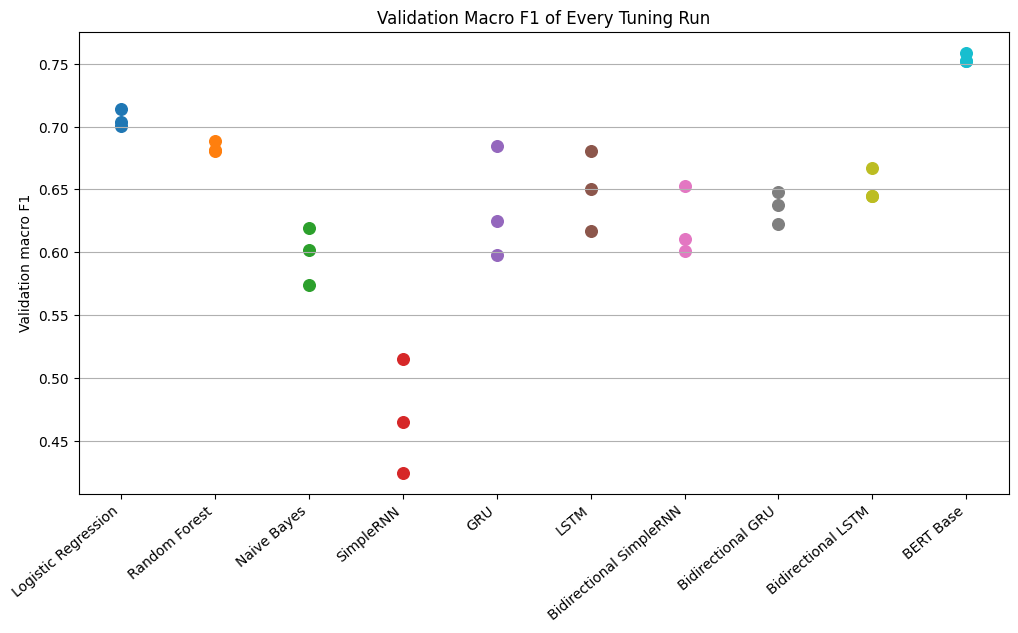

In [106]:
plt.figure(figsize=(12, 6))

for model_name in tuning_table["model"].unique():
    rows_for_model = tuning_table[tuning_table["model"] == model_name]
    plt.scatter([model_name] * len(rows_for_model), rows_for_model["val_macro_f1"], s=70)

plt.title("Validation Macro F1 of Every Tuning Run")
plt.ylabel("Validation macro F1")
plt.xticks(rotation=40, ha="right")
plt.grid(True, axis="y")
plt.savefig("results/tuning_runs.png", bbox_inches="tight")
plt.show()

### What the Tuning Showed

Thirty runs, and the pattern is clear: **tuning mattered most for the weakest models and least for the
strongest one.**

SimpleRNN had the widest spread, 0.0905 macro F1 between its best and worst configuration, while BERT had the
narrowest at 0.0067. A model with a weak inductive bias depends heavily on getting its settings right, whereas
a pretrained transformer is already close to its ceiling whatever we do to it.

Two specific results are worth noting. Naive Bayes gained the most of the classic models, rising from 0.5738
to 0.6194 simply by dropping `alpha` from 1.0 to 0.1: with a vocabulary of 10,000 features the default
smoothing is far too strong and washes out the rare words that identify the small classes. And the recurrent
models split neatly by direction. All three one directional models did best with the largest embedding
(config 3), while all three bidirectional models preferred the middle setting (config 2) - the bidirectional
versions already have twice the parameters, so adding a bigger embedding on top pushed them into overfitting.

Even so, the biggest tuning gain (0.09) is smaller than the gap between model families (0.51 to 0.77).
**Choosing the right model mattered more than tuning any of them.**

## 3.9 Model Evaluation

Each model now takes its best configuration and is evaluated on the **test set**, which no model has seen and
which was not used for any tuning decision. We report accuracy, macro F1, weighted F1, a full classification
report and a confusion matrix for every model.

In [107]:
# Test predictions, classic models

test_results = []
saved_probabilities = {}

for model_name in ["Logistic Regression", "Random Forest", "Naive Bayes"]:
    model = best_models[model_name]

    probabilities = model.predict_proba(X_test_tfidf)
    predictions = probabilities.argmax(axis=1)

    test_results.append({
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, predictions),
        "test_macro_f1": f1_score(y_test, predictions, average="macro"),
        "test_weighted_f1": f1_score(y_test, predictions, average="weighted")
    })

    saved_probabilities[model_name] = probabilities

    print(model_name, "-> accuracy:", round(accuracy_score(y_test, predictions), 4),
          "| macro F1:", round(f1_score(y_test, predictions, average="macro"), 4))

Logistic Regression -> accuracy: 0.7488 | macro F1: 0.7154


Random Forest -> accuracy: 0.7316 | macro F1: 0.6832
Naive Bayes -> accuracy: 0.685 | macro F1: 0.6299


In [108]:
# Test predictions, recurrent models

recurrent_names = ["SimpleRNN", "GRU", "LSTM",
                   "Bidirectional SimpleRNN", "Bidirectional GRU", "Bidirectional LSTM"]

for model_name in recurrent_names:
    model = best_models[model_name]

    probabilities = model.predict(X_test_pad, verbose=0)
    predictions = probabilities.argmax(axis=1)

    test_results.append({
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, predictions),
        "test_macro_f1": f1_score(y_test, predictions, average="macro"),
        "test_weighted_f1": f1_score(y_test, predictions, average="weighted")
    })

    saved_probabilities[model_name] = probabilities

    print(model_name, "-> accuracy:", round(accuracy_score(y_test, predictions), 4),
          "| macro F1:", round(f1_score(y_test, predictions, average="macro"), 4))

SimpleRNN -> accuracy: 0.6481 | macro F1: 0.5109


GRU -> accuracy: 0.7287 | macro F1: 0.6879


LSTM -> accuracy: 0.7317 | macro F1: 0.6947


Bidirectional SimpleRNN -> accuracy: 0.7087 | macro F1: 0.6612


Bidirectional GRU -> accuracy: 0.7413 | macro F1: 0.6426


Bidirectional LSTM -> accuracy: 0.7474 | macro F1: 0.6768


In [109]:
# Test predictions, BERT

bert_model = AutoModelForSequenceClassification.from_pretrained("results/models/bert_best")

evaluation_args = TrainingArguments(
    output_dir="./bert_evaluation",
    per_device_eval_batch_size=64,
    fp16=torch.cuda.is_available(),
    report_to=[],
    disable_tqdm=True
)

bert_trainer = Trainer(model=bert_model, args=evaluation_args, data_collator=data_collator)

output = bert_trainer.predict(bert_test)
logits = output.predictions
if isinstance(logits, tuple):
    logits = logits[0]

probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()
predictions = probabilities.argmax(axis=1)

test_results.append({
    "model": "BERT Base",
    "test_accuracy": accuracy_score(y_test, predictions),
    "test_macro_f1": f1_score(y_test, predictions, average="macro"),
    "test_weighted_f1": f1_score(y_test, predictions, average="weighted")
})

saved_probabilities["BERT Base"] = probabilities

print("BERT Base -> accuracy:", round(accuracy_score(y_test, predictions), 4),
      "| macro F1:", round(f1_score(y_test, predictions, average="macro"), 4))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT Base -> accuracy: 0.7863 | macro F1: 0.7679


### Results of All Ten Models

In [110]:
# Final comparison

final_results = pd.DataFrame(test_results).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
final_results.round(4)

,model,test_accuracy,test_macro_f1,test_weighted_f1
0,BERT Base,0.7863,0.7679,0.7820
1,Logistic Regression,0.7488,0.7154,0.7461
2,LSTM,0.7317,0.6947,0.7292
3,GRU,0.7287,0.6879,0.7251
4,Random Forest,0.7316,0.6832,0.7201
5,Bidirectional LSTM,0.7474,0.6768,0.7429
6,Bidirectional SimpleRNN,0.7087,0.6612,0.7092
7,Bidirectional GRU,0.7413,0.6426,0.7365
8,Naive Bayes,0.6850,0.6299,0.6773
9,SimpleRNN,0.6481,0.5109,0.6211


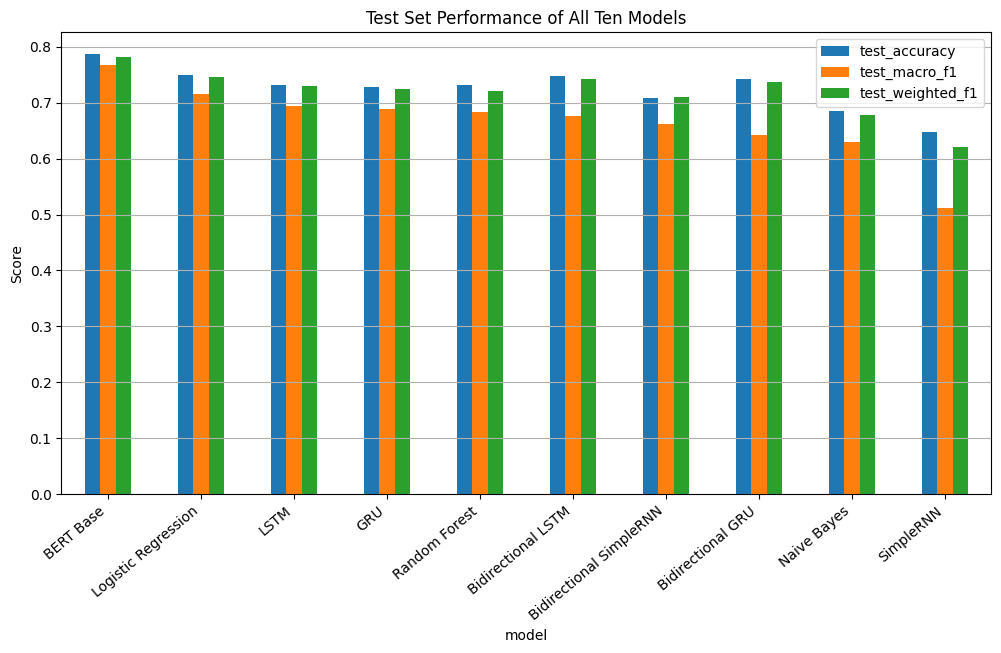

In [111]:
final_results.plot(x="model", kind="bar", figsize=(12, 6))
plt.title("Test Set Performance of All Ten Models")
plt.ylabel("Score")
plt.xticks(rotation=40, ha="right")
plt.grid(True, axis="y")
plt.savefig("results/model_comparison.png", bbox_inches="tight")
plt.show()

In [112]:
# Best and worst

best_model_row = final_results.iloc[0]
worst_model_row = final_results.iloc[-1]

print("BEST MODEL :", best_model_row["model"])
print("   accuracy   :", round(best_model_row["test_accuracy"], 4))
print("   macro F1   :", round(best_model_row["test_macro_f1"], 4))
print("   weighted F1:", round(best_model_row["test_weighted_f1"], 4))
print()
print("WORST MODEL:", worst_model_row["model"])
print("   accuracy   :", round(worst_model_row["test_accuracy"], 4))
print("   macro F1   :", round(worst_model_row["test_macro_f1"], 4))
print("   weighted F1:", round(worst_model_row["test_weighted_f1"], 4))
print()
print("Difference in macro F1:", round(best_model_row["test_macro_f1"] - worst_model_row["test_macro_f1"], 4))

BEST MODEL : BERT Base
   accuracy   : 0.7863
   macro F1   : 0.7679
   weighted F1: 0.782

WORST MODEL: SimpleRNN
   accuracy   : 0.6481
   macro F1   : 0.5109
   weighted F1: 0.6211

Difference in macro F1: 0.257


### Full Classification Report for Every Model

In [113]:
# Full report for every model

from sklearn.metrics import classification_report

for model_name in final_results["model"]:
    predictions = saved_probabilities[model_name].argmax(axis=1)

    print("=" * 78)
    print(model_name)
    print("=" * 78)
    print(classification_report(y_test, predictions, target_names=le.classes_, zero_division=0))

BERT Base
                                        precision    recall  f1-score   support

                    caution_and_advice       0.70      0.72      0.71      1070
      displaced_people_and_evacuations       0.87      0.92      0.89       790
     infrastructure_and_utility_damage       0.81      0.84      0.82      1617
                injured_or_dead_people       0.92      0.94      0.93      1447
               missing_or_found_people       0.82      0.81      0.81        72
                      not_humanitarian       0.65      0.59      0.62      1245
            other_relevant_information       0.61      0.53      0.57      2407
              requests_or_urgent_needs       0.62      0.58      0.60       521
rescue_volunteering_or_donation_effort       0.85      0.91      0.88      4218
                  sympathy_and_support       0.84      0.83      0.84      1772

                              accuracy                           0.79     15159
                            

### Confusion Matrix for Every Model

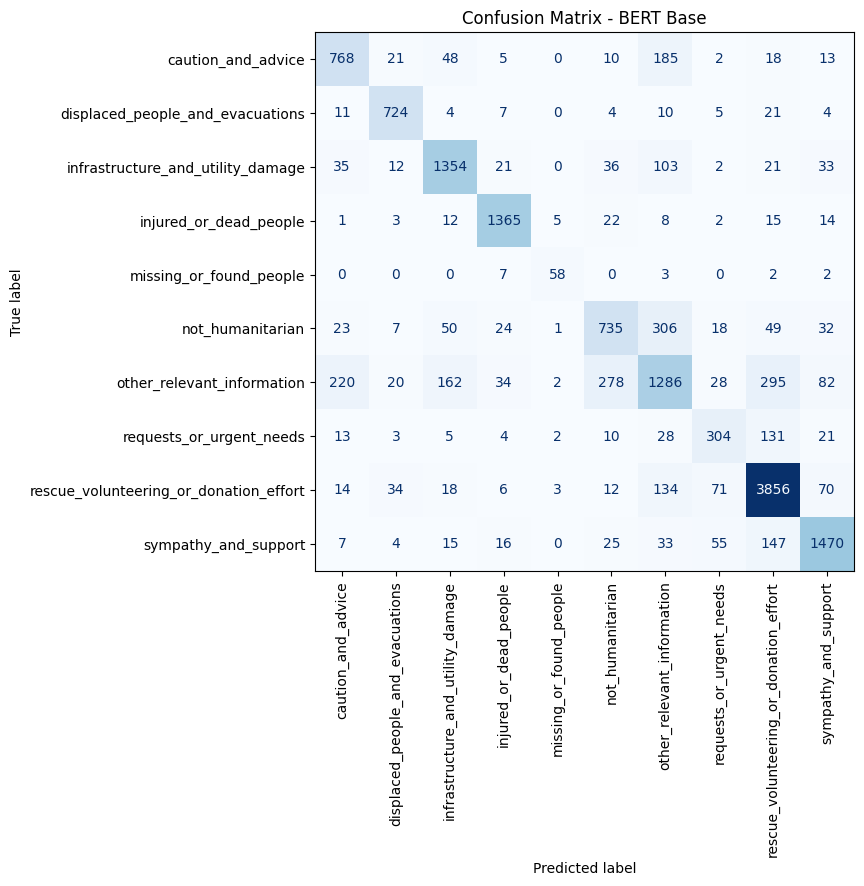

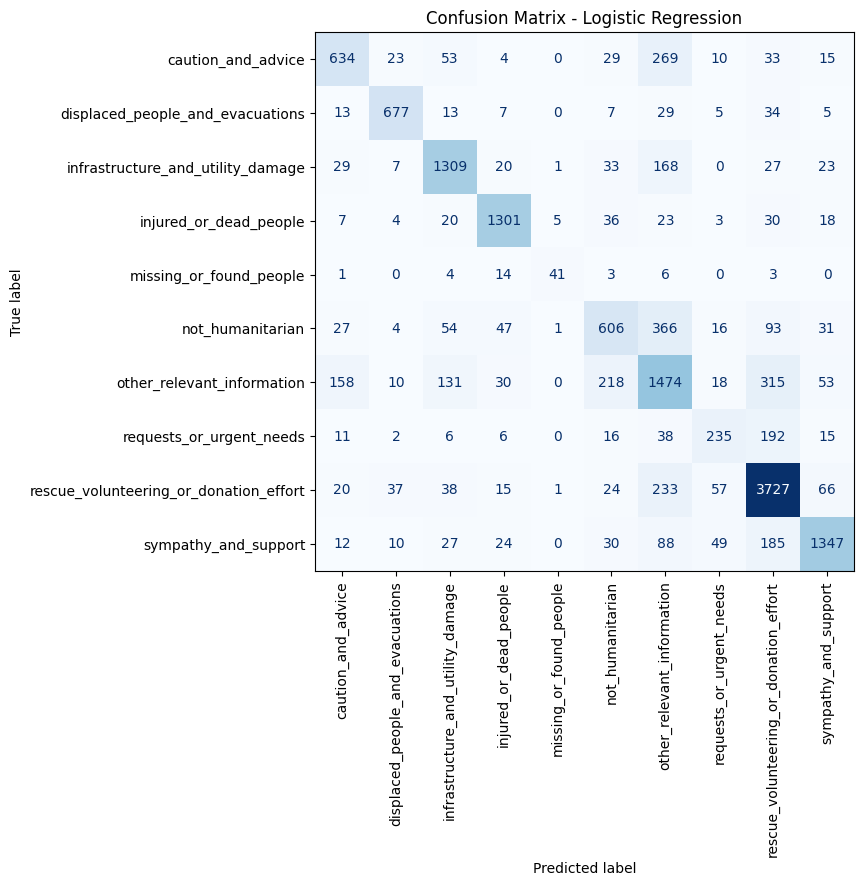

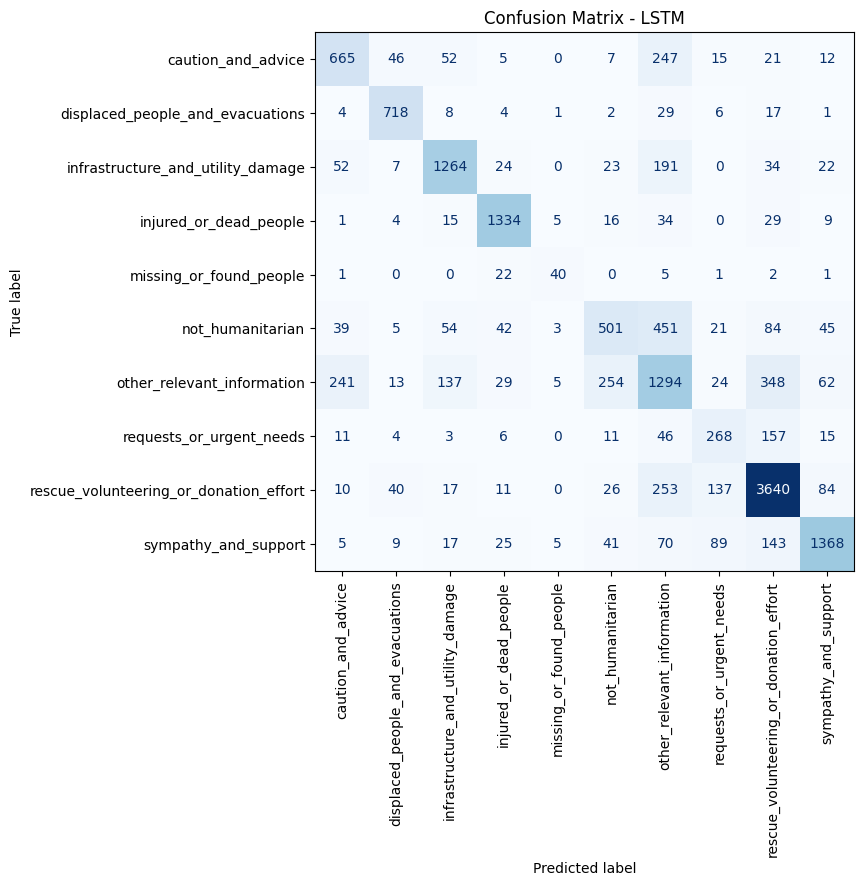

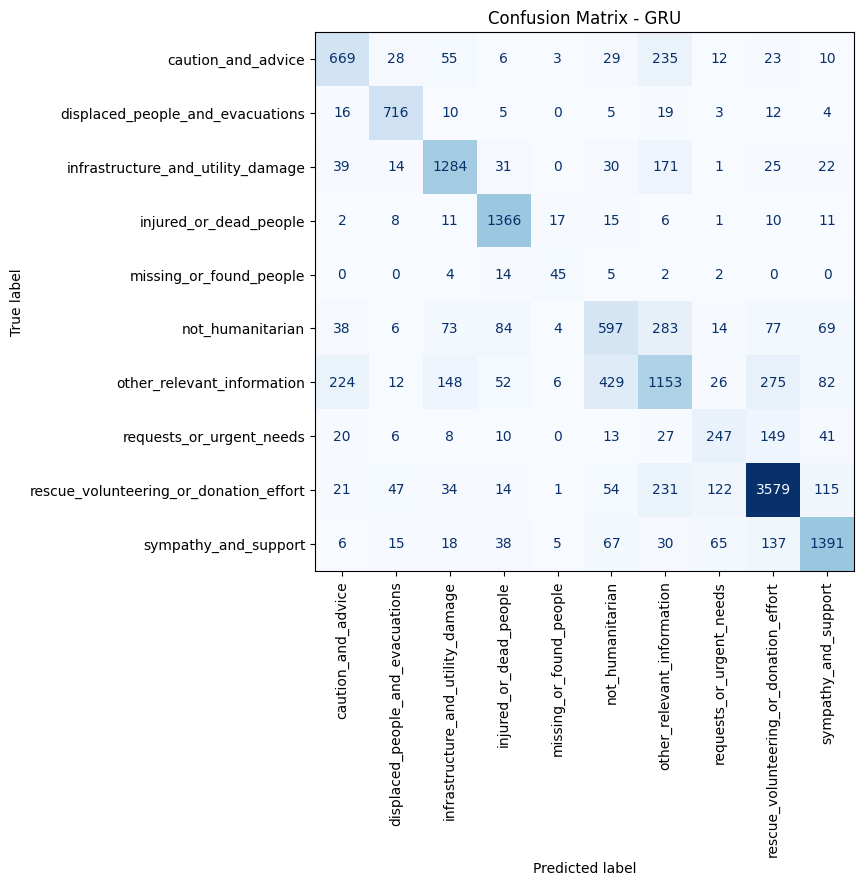

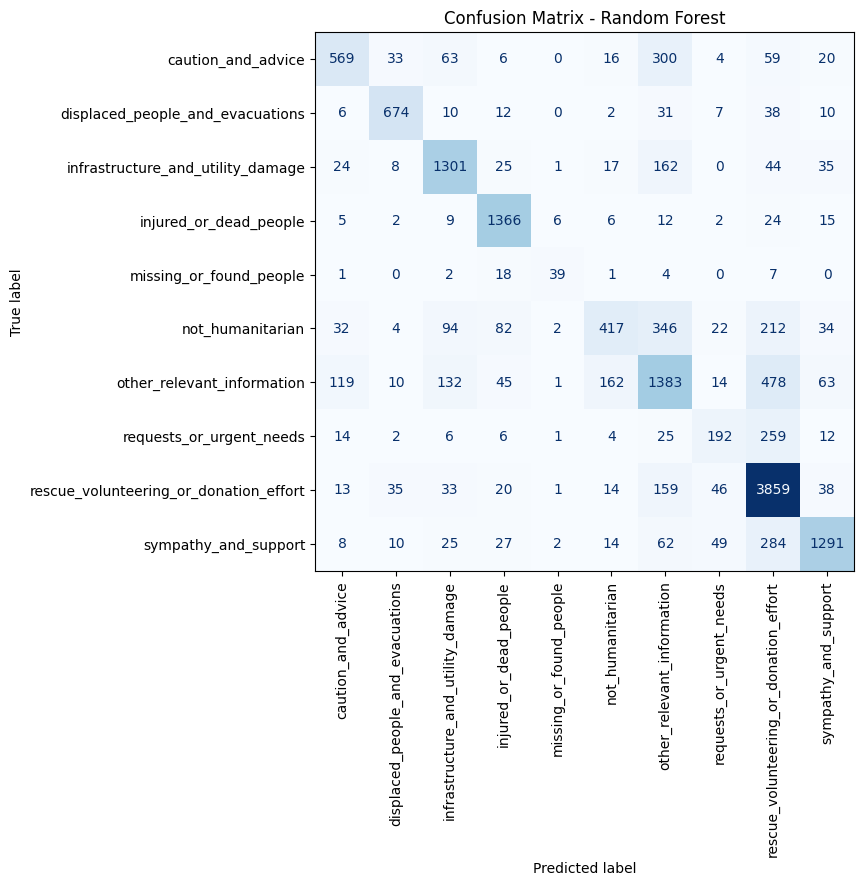

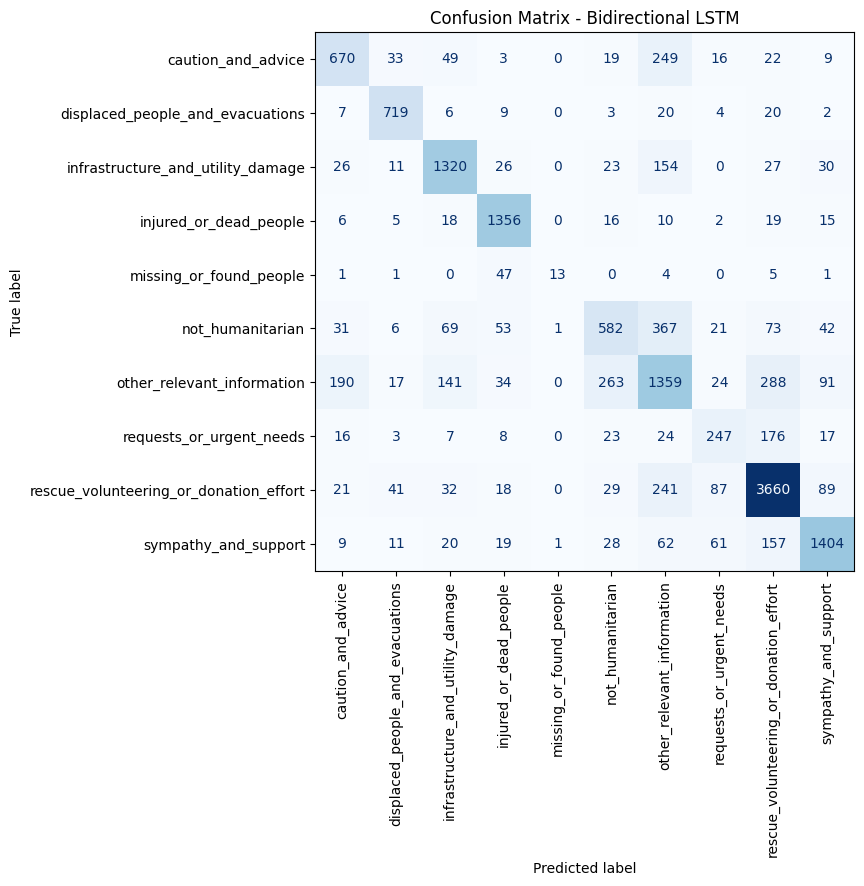

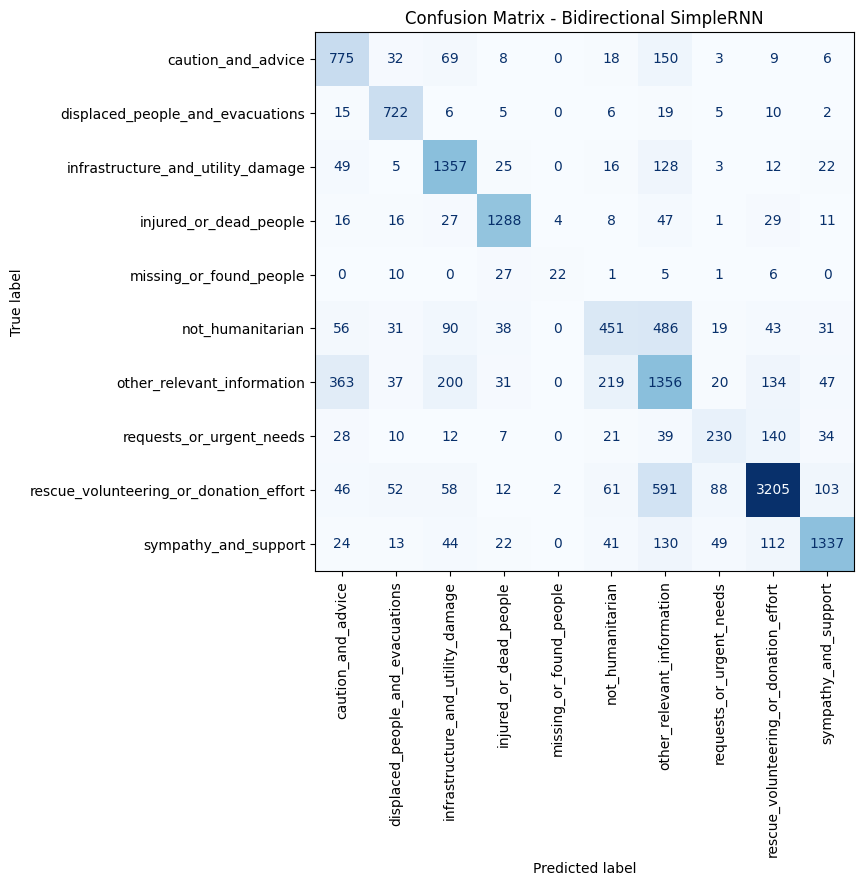

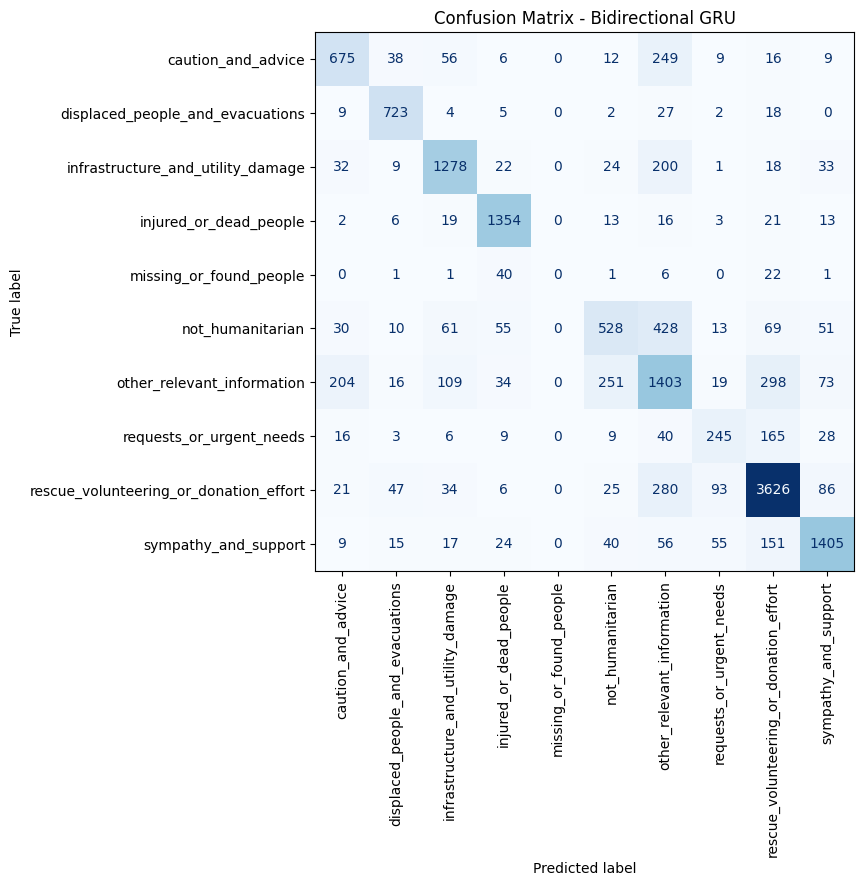

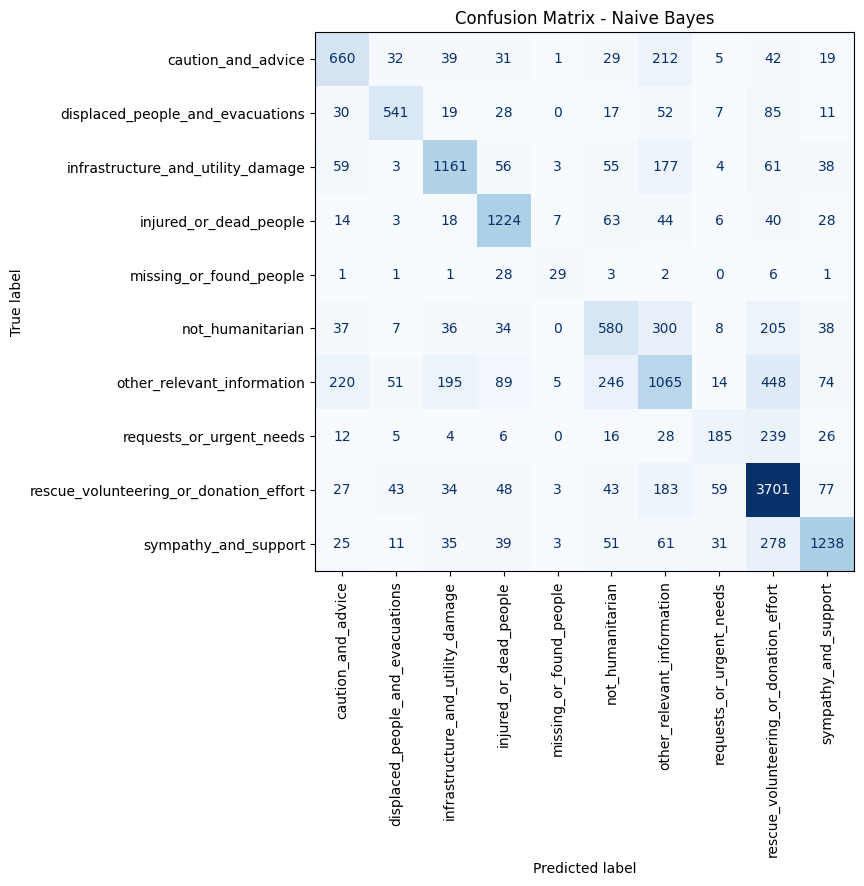

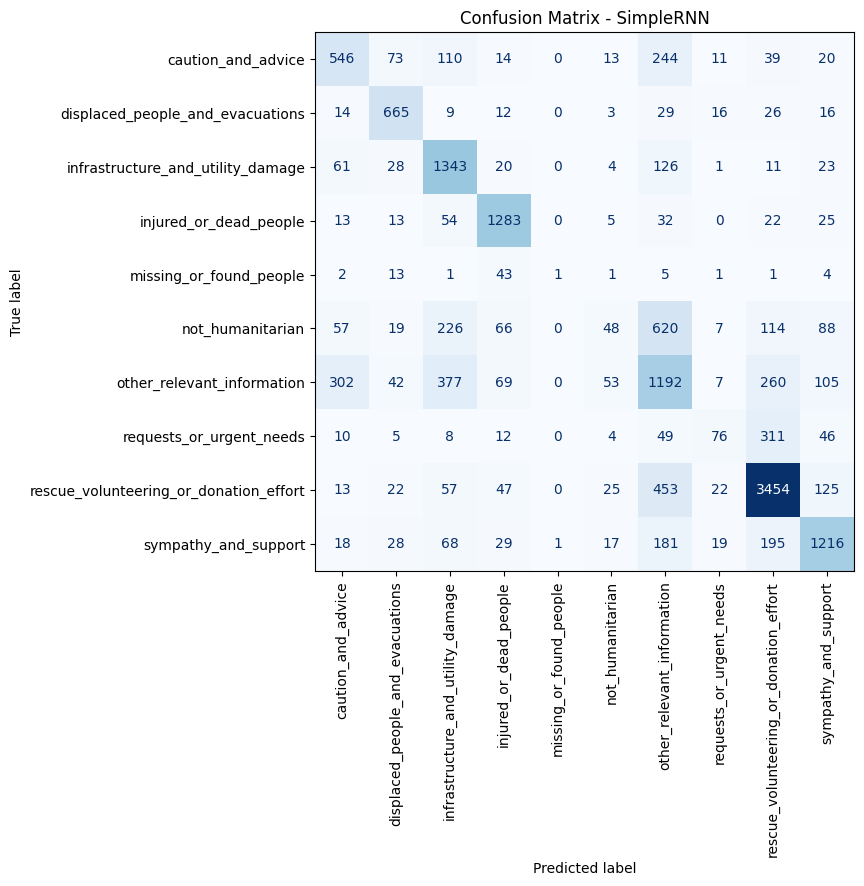

In [114]:
# Confusion matrix for every model

from sklearn.metrics import ConfusionMatrixDisplay

for model_name in final_results["model"]:
    predictions = saved_probabilities[model_name].argmax(axis=1)

    figure, axis = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions,
        display_labels=le.classes_,
        cmap="Blues",
        colorbar=False,
        xticks_rotation="vertical",
        ax=axis
    )
    axis.set_title("Confusion Matrix - " + model_name)

    file_name = "results/confusion_matrix_" + model_name.replace(" ", "_").lower() + ".png"
    plt.savefig(file_name, bbox_inches="tight")
    plt.show()

### Where the Models Struggle

The confusion matrices show the mistakes, but it is easier to see the pattern by looking at the F1 of each
class for the best and the worst model side by side.

In [115]:
# Per class F1, best model against worst

best_predictions = saved_probabilities[best_model_row["model"]].argmax(axis=1)
worst_predictions = saved_probabilities[worst_model_row["model"]].argmax(axis=1)

per_class = pd.DataFrame({
    "class": le.classes_,
    "training_tweets": train_df.value_counts("class_label")[le.classes_].values,
    "best_model_f1": f1_score(y_test, best_predictions, average=None).round(4),
    "worst_model_f1": f1_score(y_test, worst_predictions, average=None).round(4)
})

per_class.sort_values("training_tweets")

,class,training_tweets,best_model_f1,worst_model_f1
4,missing_or_found_people,250,0.8112,0.0270
7,requests_or_urgent_needs,1833,0.6032,0.2232
1,displaced_people_and_evacuations,2800,0.8949,0.7833
0,caution_and_advice,3774,0.7105,0.5185
5,not_humanitarian,4407,0.6184,0.0677
3,injured_or_dead_people,5110,0.9298,0.8435
2,infrastructure_and_utility_damage,5715,0.8244,0.6941
9,sympathy_and_support,6250,0.8369,0.7070
6,other_relevant_information,8501,0.5712,0.4466
8,rescue_volunteering_or_donation_effort,14891,0.8791,0.7985


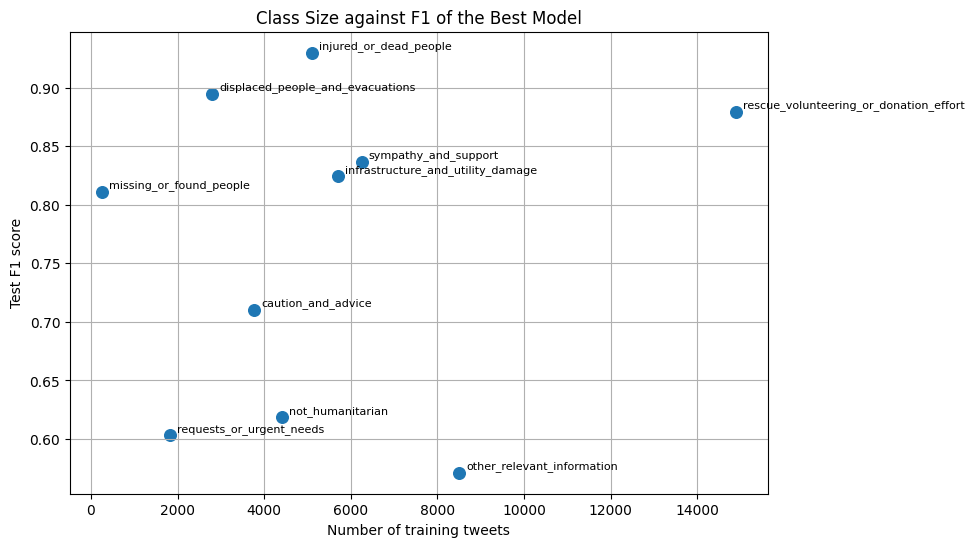

In [116]:
# Does a class with more training data get a better score?

plt.figure(figsize=(9, 6))
plt.scatter(per_class["training_tweets"], per_class["best_model_f1"], s=70)

for i in range(len(per_class)):
    plt.annotate(per_class["class"][i], (per_class["training_tweets"][i], per_class["best_model_f1"][i]),
                 fontsize=8, xytext=(5, 3), textcoords="offset points")

plt.title("Class Size against F1 of the Best Model")
plt.xlabel("Number of training tweets")
plt.ylabel("Test F1 score")
plt.grid(True)
plt.savefig("results/class_size_vs_f1.png", bbox_inches="tight")
plt.show()

### Discussion: Why the Models Performed as They Did

**Why BERT won (0.7679 macro F1).** BERT is the only model here that did not have to learn language from our
53,000 tweets. It arrives pretrained on billions of words and produces a *contextual* vector, so the same word
gets a different representation depending on its neighbours, and its self attention reads the whole tweet at
once instead of one word at a time. That is exactly what this dataset needs: 3.3 showed the tweets are short
(median 19 words) and that several classes share vocabulary, so the deciding information is in the context,
not in which words are present.

**Why Logistic Regression beat every neural network (0.7154).** This looks surprising but follows from the
EDA. In 3.3 the per class word lists were genuinely distinctive - *prayers* and *thoughts* for sympathy,
*donate* and *relief* for donations, *missing* and *search* for missing people. When classes separate on
vocabulary, TF-IDF with 10,000 sparse features is close to ideal and a linear model can weight each word
directly. The recurrent models, by contrast, had to learn word meanings from scratch from only 53,000 short
tweets, which is not enough to beat well weighted word counts.

**Why SimpleRNN was worst (0.5109).** It has no gating, so gradients vanish across the 50 timesteps and it
cannot hold information from the start of a tweet to the end. The damage is visible per class: it scored 0.0270
on `missing_or_found_people` and 0.0677 on `not_humanitarian`, meaning it effectively gave up on the small
classes and collapsed onto the large ones. Adding gates fixes this - GRU reached 0.6879 and LSTM 0.6947, a gain
of about 0.18 over SimpleRNN from the gating mechanism alone.

**Why bidirectionality did not reliably help.** Bidirectional GRU (0.6426) scored *below* plain GRU (0.6879),
and Bidirectional LSTM (0.6768) below plain LSTM (0.6947). Reading backwards doubles the parameters, and with a
median tweet of 19 words there is little long range dependency to recover in reverse, so the extra capacity
mostly overfits. The one exception proves the rule: Bidirectional SimpleRNN (0.6612) beat plain SimpleRNN
(0.5109) by a wide margin, because for a model that cannot carry information far, reading from both ends
shortens the distance any signal has to travel.

**Where all models failed, and why.** In 3.3 we predicted that `other_relevant_information` and
`not_humanitarian` would be hardest, because their frequent words overlapped with every other class. That
prediction held: they are BERT's two weakest classes (0.5712 and 0.6184), and **69.6% of all BERT errors
involve one of them**. These two are confused with each other in both directions, which is the signature of
overlapping class *definitions* rather than a weak model - `other_relevant_information` is a catch all, so its
boundary sits wherever the annotator drew it.

**The result that overturned our expectation.** We assumed the rarest class would be the hardest. It was not.
`missing_or_found_people`, with only 250 training tweets, reached 0.8112 F1, while
`other_relevant_information`, with 8,501 tweets, managed only 0.5712 - thirty four times the data for a much
worse score. What decided difficulty was not class size but whether the class has a **clear, distinctive
vocabulary**, and 3.3 had already shown that *missing*, *search* and *still missing* form exactly that kind of
sharp signature.

**On the metric.** Everything above is reported in macro F1 rather than accuracy, and the reason is in 3.3: at
a 60 to 1 imbalance, always guessing the largest class already yields 28% accuracy. Macro F1 is the metric
that cannot be fooled by ignoring the small classes, and it is what exposed SimpleRNN scoring 0.0270 on the
rarest class while still reaching 64.8% accuracy.